# Taller 1. Script 2
****
**Universidad Externado de Colombia**

**Maestria Inteligencia de Negocios**

**Seminario de Programacion**

**Integrantes:**

* Pablo Alejandro Reyes Granados

****

## Motivacion del segundo Script

En esta segunda etapa incorporaremos nuevas variables que nos permitan explorar las posibles relaciones y determinantes del fenómeno del secuestro en Colombia. Primero, calcularemos **tasas de secuestro por cada 100 000 habitantes** utilizando población municipal y departamental para normalizar los conteos absolutos. Posteriormente fusionaremos indicadores socioeconómicos clave, obtenidos de fuentes oficiales como DANE y SISBEN, entre ellos el **PIB per cápita**, el **índice de pobreza multidimensional** y la **tasa de acceso a educación**. También añadiremos información sobre **otros delitos** (homicidio, extorsión, hurto) y la **presencia histórica de grupos armados** (FARC, ELN, AUC, disidencias) para evaluar su correlación espacial y temporal con las tasas de secuestro. Con este dataset enriquecido, avanzaremos hacia un análisis multivariante y la construcción de modelos que ayuden a identificar los factores más relevantes y sus interacciones.  

***
# 1. Construccion de las bases 
***

In [117]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import geopandas as gpd
from mpl_toolkits.axes_grid1 import make_axes_locatable
import contextily as ctx
import calendar
import warnings
pd.options.mode.chained_assignment = None 
from sklearn.cluster import DBSCAN
import re
from collections import defaultdict

from construccion_bases_series import *

In [118]:
poblacion_dept_2004 = pd.read_excel('C:\\Users\\alejo\\OneDrive\\Escritorio\\Universidaad\\Maestria Inteligencia de negocios\\Segundo Semestre\\Seminario Programacion\\Proyecto 1\\Datos\\Poblacion 1993-2004.xlsx')
poblacion_dept_2019 = pd.read_excel('C:\\Users\\alejo\\OneDrive\\Escritorio\\Universidaad\\Maestria Inteligencia de negocios\\Segundo Semestre\\Seminario Programacion\\Proyecto 1\\Datos\\Poblacion 2005-2019.xlsx')
poblacion_dept_2025 = pd.read_excel('C:\\Users\\alejo\\OneDrive\\Escritorio\\Universidaad\\Maestria Inteligencia de negocios\\Segundo Semestre\\Seminario Programacion\\Proyecto 1\\Datos\\Poblacion 2020-2025.xlsx')

In [119]:
print(poblacion_dept_2004.shape , poblacion_dept_2019.shape , poblacion_dept_2025.shape)

(1188, 5) (1485, 5) (2079, 5)


In [120]:
if poblacion_dept_2004.columns.equals(poblacion_dept_2019.columns) and poblacion_dept_2004.columns.equals(poblacion_dept_2025.columns):
    print(f'Todas las bases tienen las mismas columnas ')

Todas las bases tienen las mismas columnas 


Debido a que las 3 bases tienen las mismas cantidades de columnas podemos apilarlas horizontalmente para quedarnos por la serie de la poblacion en el mismo periodo de nuestra serie de secuestros 

In [121]:
serie_poblacion = pd.concat([poblacion_dept_2004, poblacion_dept_2019 , poblacion_dept_2025], axis=0, ignore_index=True)
serie_poblacion = serie_poblacion[(serie_poblacion['AÑO'] < 2026) & (serie_poblacion['ÁREA GEOGRÁFICA'] == 'Total')] #Filtramos para solo dejar hasta 2025 y el total de la poblacion
serie_poblacion  

,DP,DPNOM,AÑO,ÁREA GEOGRÁFICA,Población
2,5,Antioquia,1993,Total,4607874
5,5,Antioquia,1994,Total,4679652
8,5,Antioquia,1995,Total,4753428
11,5,Antioquia,1996,Total,4828617
14,5,Antioquia,1997,Total,4904267
...,...,...,...,...,...
4694,99,Vichada,2021,Total,118270
4697,99,Vichada,2022,Total,120942
4700,99,Vichada,2023,Total,123304
4703,99,Vichada,2024,Total,125477


### Podemos hacer lo mismo con la series municipales 

In [122]:
poblacion_mun_2004 = pd.read_excel('C:\\Users\\alejo\\OneDrive\\Escritorio\\Universidaad\\Maestria Inteligencia de negocios\\Segundo Semestre\\Seminario Programacion\\Proyecto 1\\Datos\\Poblacion-Mun 1995-2004.xlsx')
poblacion_mun_2019 = pd.read_excel('C:\\Users\\alejo\\OneDrive\\Escritorio\\Universidaad\\Maestria Inteligencia de negocios\\Segundo Semestre\\Seminario Programacion\\Proyecto 1\\Datos\\Poblacion-Mun 2005-2019.xlsx')
poblacion_mun_2025 = pd.read_excel('C:\\Users\\alejo\\OneDrive\\Escritorio\\Universidaad\\Maestria Inteligencia de negocios\\Segundo Semestre\\Seminario Programacion\\Proyecto 1\\Datos\\Poblacion-Mun 2020-2025.xlsx')

## Para la segunda base se intercalaron las columnas...
cols = list(poblacion_mun_2019.columns)
cols[2], cols[3] = cols[3], cols[2]
poblacion_mun_20191 = poblacion_mun_2019[cols]
poblacion_mun_2004.columns = poblacion_mun_2025.columns

In [123]:
serie_poblacion_mun = pd.concat([poblacion_mun_2004, poblacion_mun_20191 , poblacion_mun_2025], axis=0, ignore_index=True)
serie_poblacion_mun = serie_poblacion_mun[(serie_poblacion_mun['AÑO'] < 2026) & (serie_poblacion_mun['ÁREA GEOGRÁFICA'] == 'Total')] #Filtramos para solo dejar hasta 2025 y el total de la poblacion
serie_poblacion_mun  

,DP,DPNOM,MPIO,DPMP,AÑO,ÁREA GEOGRÁFICA,Población
2,5,Antioquia,5001,Medellín,1995,Total,1756761
5,5,Antioquia,5001,Medellín,1996,Total,1787831
8,5,Antioquia,5001,Medellín,1997,Total,1816301
11,5,Antioquia,5001,Medellín,1998,Total,1847391
14,5,Antioquia,5001,Medellín,1999,Total,1877865
...,...,...,...,...,...,...,...
137963,99,Vichada,99773,Cumaribo,2021,Total,81958
137966,99,Vichada,99773,Cumaribo,2022,Total,83791
137969,99,Vichada,99773,Cumaribo,2023,Total,85539
137972,99,Vichada,99773,Cumaribo,2024,Total,87018


## Cargamos las bases que creamos en el script pasado y unamos con la variable de poblacion con ayuda de la funcion creada en el scritp de bases de datos

In [124]:
secuestros = pd.read_csv('C:\\Users\\alejo\\OneDrive\\Escritorio\\Universidaad\\Maestria Inteligencia de negocios\\Segundo Semestre\\Seminario Programacion\\Proyecto 1\\Datos\\SECUESTRO_20250630.csv')

municipios_mensual , departamentos_mensual , municipios_anual , departamentos_anual  , serie_colombia_mensual = crear_series_de_tiempo(verificar_base , secuestros)

Fechas inválidas: 0


In [125]:
# Series mensuales 
municipios_mensual = concatenar_poblacion(municipios_mensual , serie_poblacion_mun , 'MES' , 'MUN')
departamentos_mensual = concatenar_poblacion(departamentos_mensual , serie_poblacion , 'MES' , 'DEP')

# Series Anuales
municipios_anual = concatenar_poblacion(municipios_anual , serie_poblacion_mun , 'AÑO' , 'MUN')
departamentos_anual = concatenar_poblacion(departamentos_anual , serie_poblacion , 'AÑO' , 'DEP')

### Visualizar los DataFrame Unidos 

In [126]:
departamentos_mensual

,MES,COD_DEPTO,DEPARTAMENTO,N_SIMPLE,N_EXTORSIVO,TOTAL,AÑO,Población
0,1996-01-31,5,ANTIOQUIA,1,36,37,1996,4828617
1,1996-01-31,8,ATLANTICO,0,5,5,1996,1802161
2,1996-01-31,11,BOGOTA D.C.,0,8,8,1996,5614203
3,1996-01-31,13,BOLIVAR,0,2,2,1996,1559366
4,1996-01-31,15,BOYACA,0,2,2,1996,1098694
...,...,...,...,...,...,...,...,...
5257,2025-04-30,5,ANTIOQUIA,0,10,10,2025,6951825
5258,2025-04-30,19,CAUCA,1,2,3,2025,1590171
5259,2025-04-30,20,CESAR,0,1,1,2025,1414859
5260,2025-04-30,54,NORTE DE SANTANDER,2,0,2,2025,1717992


In [12]:
municipios_anual

,AÑO,COD_DEPTO,DEPARTAMENTO,COD_MUNI,MUNICIPIO,N_SIMPLE,N_EXTORSIVO,TOTAL,Población
0,1996,5,ANTIOQUIA,5001,MEDELLIN,8,73,81,1787831
1,1996,5,ANTIOQUIA,5002,ABEJORRAL,0,2,2,25094
2,1996,5,ANTIOQUIA,5030,AMAGA,0,2,2,25201
3,1996,5,ANTIOQUIA,5031,AMALFI,1,1,2,20966
4,1996,5,ANTIOQUIA,5034,ANDES,0,2,2,41359
...,...,...,...,...,...,...,...,...,...
6595,2025,81,ARAUCA,81065,ARAUQUITA,4,0,4,64172
6596,2025,81,ARAUCA,81736,SARAVENA,4,0,4,65754
6597,2025,81,ARAUCA,81794,TAME,5,0,5,54772
6598,2025,85,CASANARE,85001,YOPAL,0,1,1,196758


### Ahora podemos hacer lo mismo pero para la serie mensual del total de secuestros en el Pais

In [20]:
total_poblacion_anual = (serie_poblacion.groupby('AÑO', as_index=False)['Población'].sum())

serie_colombia_mensual = serie_colombia_mensual.rename(columns={'AÑO': 'Fecha'})
serie_colombia_mensual['AÑO'] = serie_colombia_mensual['Fecha'].dt.year.astype(int)
serie_colombia_mensual = serie_colombia_mensual.merge(total_poblacion_anual[[ 'Población' ,'AÑO' ]], 
                              on='AÑO' , how='left' ,suffixes=('','_agg'))

serie_colombia_mensual

,Fecha,N_SIMPLE,N_EXTORSIVO,TOTAL,AÑO,Población
0,1996-01-31,1,103,104,1996,36830574
1,1996-02-29,1,76,77,1996,36830574
2,1996-03-31,6,94,100,1996,36830574
3,1996-04-30,15,72,87,1996,36830574
4,1996-05-31,11,84,95,1996,36830574
...,...,...,...,...,...,...
347,2024-12-31,5,22,27,2024,52695952
348,2025-01-31,5,17,22,2025,53110609
349,2025-02-28,6,22,28,2025,53110609
350,2025-03-31,11,51,62,2025,53110609


***
# 2. Cálculo de tasas de secuestro anuales por municipio y departamento
***

In [21]:
def tasa_secuestro(df , year = False):
    '''
    Añade al DataFrame la tasa de secuestros por 100000 habitantes. 
    En caso de que la serie sea para toda colombia, se calcula la tasa por millon de habitantes

    Devuelve
    -------
    pandas.DataFrame
        El mismo DataFrame con una nueva columna:
        - 'Tasa_100k': secuestros estandarizados a 100 000 habitantes.
    '''

    df['Tasa_100k'] = (df['TOTAL'] / df['Población']) * 100000
    
    if year: 
        df['Tasa_100k'] = (df['TOTAL'] / df['Población']) * 1000000
    return df

municipios_mensual = tasa_secuestro(municipios_mensual)
departamentos_mensual = tasa_secuestro(departamentos_mensual)

municipios_anual = tasa_secuestro(municipios_anual)
departamentos_anual = tasa_secuestro(departamentos_anual)

serie_colombia_mensual = tasa_secuestro(serie_colombia_mensual , year=True)

## Paneles Mensuales

In [22]:
municipios_mensual.sort_values('Tasa_100k', ascending=False).head(15)

,MES,COD_DEPTO,DEPARTAMENTO,COD_MUNI,MUNICIPIO,N_SIMPLE,N_EXTORSIVO,TOTAL,AÑO,Población,Tasa_100k
2136,1998-08-31,95,GUAVIARE,95200,MIRAFLORES,0,76,76,1998,6334,1199.873698
2424,1998-11-30,97,VAUPES,97001,MITU,0,68,68,1998,13257,512.936562
1626,1998-03-31,25,CUNDINAMARCA,25335,GUAYABETAL,4,20,24,1998,4704,510.204082
4021,2000-03-31,5,ANTIOQUIA,5321,GUATAPE,26,1,27,2000,6146,439.310120
7349,2002-11-30,85,CASANARE,85015,CHAMEZA,9,1,10,2002,2282,438.212095
1167,1997-09-30,52,NARIÑO,52405,LEIVA,0,41,41,1997,9830,417.090539
7055,2002-08-31,27,CHOCO,27075,BAHIA SOLANO,0,30,30,2002,7349,408.218805
8694,2004-04-30,97,VAUPES,97161,CARURU,0,7,7,2004,1817,385.250413
3117,1999-06-30,85,CASANARE,85225,NUNCHIA,0,21,21,1999,6822,307.827617
4079,2000-03-31,25,CUNDINAMARCA,25426,MACHETA,5,15,20,2000,7344,272.331155


En municipios pequeños (todos con población <15 000), incluso unos pocos secuestros al mes inflan la tasa por encima de 200–1 200 por 100 000 hab., como en Miraflores (1 200) que verdadermanete es un caso excepcional, dado que en agosto del 98 se presento el mes con mayor secuestros para un municipio en toda la historia del pais. Esto muestra que el riesgo relativo es muy alto en localidades de baja densidad: un solo evento puede traducirse en un pico en la tasa mensual, aunque el conteo absoluto siga siendo bajo.   

Todas estas tasas elevadas ocurren entre finales de los 90 y comienzos de los 2000, justo cuando la violencia alcanzaba su punto más crítico en Colombia. Por ejemplo, Miraflores en agosto de 1998, Mitú en noviembre de 1998 o Guatapé en marzo de 2000 reflejan meses de intensa actividad guerrillera y paramilitar, donde incluso unos pocos casos disparaban la tasa debido a la baja población local.  



In [137]:
departamentos_mensual.sort_values('Tasa_100k', ascending=False).head(15)

,MES,COD_DEPTO,DEPARTAMENTO,N_SIMPLE,N_EXTORSIVO,TOTAL,AÑO,Población,Tasa_100k
764,1998-11-30,97,VAUPES,0,68,68,1998,18227,373.072914
692,1998-08-31,95,GUAVIARE,0,76,76,1998,69013,110.124180
2332,2004-04-30,97,VAUPES,0,8,8,2004,24236,33.008747
526,1998-01-31,99,VICHADA,0,12,12,1998,62099,19.323983
888,1999-04-30,94,GUAINIA,0,4,4,1999,24359,16.421035
1483,2001-04-30,81,ARAUCA,1,25,26,2001,215899,12.042668
2711,2005-11-30,95,GUAVIARE,8,0,8,2005,73296,10.914647
939,1999-06-30,85,CASANARE,1,27,28,1999,281194,9.957538
575,1998-03-31,99,VICHADA,0,6,6,1998,62099,9.661991
1038,1999-10-31,99,VICHADA,6,0,6,1999,64195,9.346522



En el ranking mensual por departamento destacan tasas extraordinarias en Vaupés (373/100000 en nov-1998) y Guaviare (110/100000 en ago-1998), seguidas de cifras elevadas en periodos como abril de 2004 en Vaupés (33/100000). Estas cifras tan desproporcionadas ocurren todas entre finales de los 90 y principios de los 2000, coincidiendo con el apogeo de las FARC y la consolidación de los bloques paramilitares, cuando incluso unos pocos secuestros disparaban la tasa en regiones de baja población. Además, la mayoría de los departamentos que aparecen varias veces, Caquetá, Guaviare, Vichada, Arauca, Chocó, son justamente territorios reconocidos por su histórica presencia guerrillera y de grupos armados, lo que explica su marcada vulnerabilidad en aquel periodo.  


## Paneles Anuales 

In [138]:
municipios_anual.sort_values('Tasa_100k', ascending=False).head(15)

,AÑO,COD_DEPTO,DEPARTAMENTO,COD_MUNI,MUNICIPIO,N_SIMPLE,N_EXTORSIVO,TOTAL,Población,Tasa_100k
1143,1998,95,GUAVIARE,95200,MIRAFLORES,0,76,76,6334,1199.873698
890,1998,25,CUNDINAMARCA,25335,GUAYABETAL,6,23,29,4704,616.496599
1144,1998,97,VAUPES,97001,MITU,0,68,68,13257,512.936562
2686,2002,5,ANTIOQUIA,5660,SAN LUIS,33,36,69,13664,504.976581
3088,2002,85,CASANARE,85015,CHAMEZA,9,2,11,2282,482.033304
2876,2002,27,CHOCO,27075,BAHIA SOLANO,0,35,35,7349,476.255273
1718,2000,5,ANTIOQUIA,5321,GUATAPE,26,1,27,6146,439.310120
541,1997,52,NARIÑO,52405,LEIVA,0,41,41,9830,417.090539
2683,2002,5,ANTIOQUIA,5652,SAN FRANCISCO,3,22,25,6096,410.104987
3896,2004,97,VAUPES,97161,CARURU,0,7,7,1817,385.250413


En el ranking anual por municipio vuelven a dominar localidades de baja población: Miraflores (Guaviare) lidera con casi 1 200 secuestros por 100 000 hab. en 1998, seguido de Guayabetal (Cundinamarca) y Mitú (Vaupés) con más de 500 en sus años pico. También aparecen San Luis (Antioquia) y Chámeza (Casanare) durante 2002–2003 en torno a 480–505 por 100 000. Estos valores ocurren todos entre fines de los 90 y principios de los 2000, cuando la violencia guerrillera y paramilitar alcanzó su máxima intensidad y, en municipios muy pequeños, unos pocos casos elevaron las tasas anuales a niveles extremos.  

Es importante notar que, la mayoría de estos incidentes fueron secuestros extorsivos, lo que sugiere que muchas de estas cifras responden a las conocidas “pescas milagrosas” en pequeñas comunidades bajo control de grupos armados.  



In [139]:
departamentos_anual.sort_values('Tasa_100k', ascending=False).head(15)

,AÑO,COD_DEPTO,DEPARTAMENTO,N_SIMPLE,N_EXTORSIVO,TOTAL,Población,Tasa_100k
86,1998,97,VAUPES,0,68,68,18227,373.072914
85,1998,95,GUAVIARE,0,76,76,69013,110.124180
155,2001,20,CESAR,280,118,398,888830,44.777967
172,2001,85,CASANARE,109,16,125,295715,42.270429
66,1998,20,CESAR,73,250,323,840167,38.444738
143,2000,85,CASANARE,58,50,108,288447,37.441887
113,1999,85,CASANARE,11,88,99,281194,35.207010
183,2002,20,CESAR,160,142,302,904392,33.392600
265,2004,97,VAUPES,0,8,8,24236,33.008747
83,1998,85,CASANARE,18,71,89,273971,32.485190


Con esta tabla podemos ver algo sorprendete, el primer lugar tanto en la serie mensual como en la anual lo ocupa Vaupés con 68 secuestros y una tasa de 373/100000 hab. en noviembre de 1998, lo que implica que **todos los secuestros reportados en ese departamento durante 1998 ocurrieron en ese único mes**.

Por su parte, el departamento de Cesar aparece repetidamente en varios años, destacando especialmente en **2001 con 398 secuestros** (280 simples y 118 extorsivos), y también con cifras elevadas en 1998 (323 casos), 2002 (302 casos) y 2000 (282 casos). Esto subraya la persistente actividad de secuestro en Cesar a lo largo del pico de la violencia, con predominio de la modalidad simple en 2001.  

De manera similar, Casanare registra tasas muy altas en años como 2001 (125 casos) y 1999 (99 casos), reflejando un fuerte componente extorsivo ligado a actividades de grupos armados en los Llanos. Guaviare y Vaupés, en cambio, presentan sus picos históricos hacia finales de los 90, donde la casi totalidad de los secuestros anuales se concentró en un único mes, evidencia de “pescas milagrosas” en municipios de baja población.  



### Grafica de la tasa de secuestro departamentalmente 

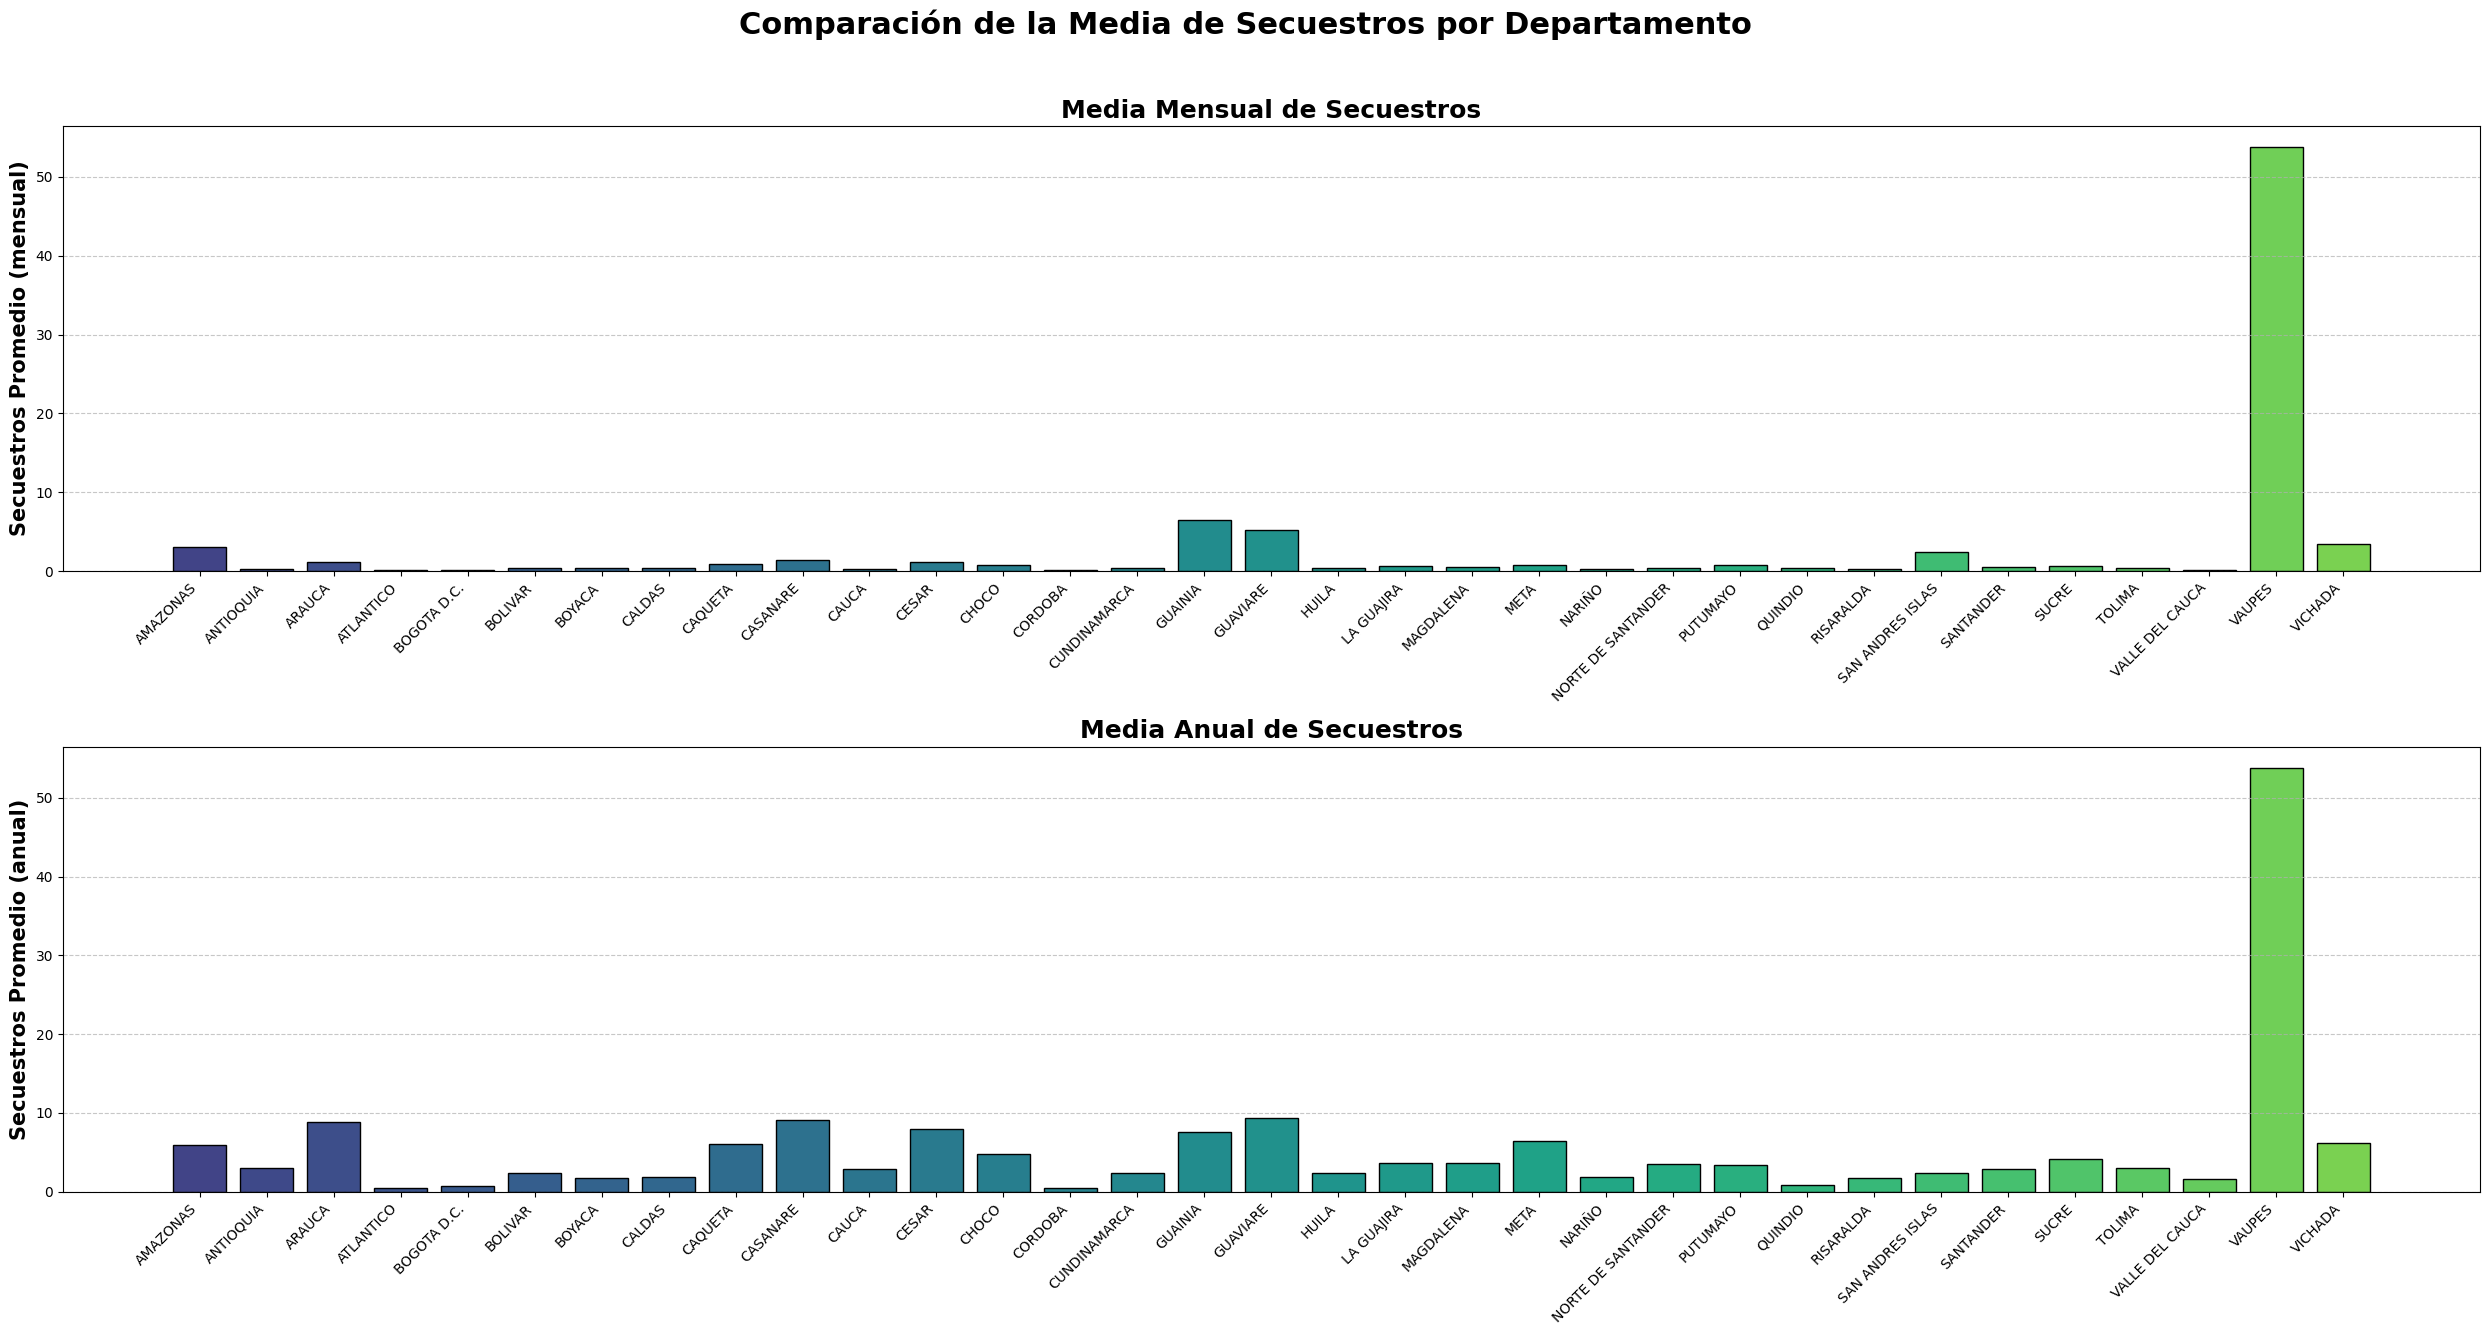

In [23]:
mean_dept_anaul = departamentos_anual.groupby('DEPARTAMENTO')['Tasa_100k'].mean().reset_index()
mean_dept_mens = departamentos_mensual.groupby('DEPARTAMENTO')['Tasa_100k'].mean().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(25, 14), sharex=False)
fig.suptitle('Comparación de la Media de Secuestros por Departamento',fontsize=22, fontweight='bold', y=0.95)

cmap = plt.cm.viridis    

x_mensual = np.arange(len(mean_dept_anaul))
colors_mensual = cmap(np.linspace(0.2, 0.8, len(x_mensual)))
bars1 = axes[0].bar(
    x_mensual,
    mean_dept_mens['Tasa_100k'],
    color=colors_mensual,
    edgecolor='black')
axes[0].set_title('Media Mensual de Secuestros', fontsize=18, fontweight='bold')
axes[0].set_ylabel('Secuestros Promedio (mensual)', fontsize=15, fontweight='bold')
axes[0].set_xticks(x_mensual)
axes[0].set_xticklabels(mean_dept_mens['DEPARTAMENTO'], rotation=45, ha='right', fontsize=10)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

x_anual = np.arange(len(mean_dept_mens))
colors_anual = cmap(np.linspace(0.2, 0.8, len(x_anual)))
bars2 = axes[1].bar(
    x_anual,
    mean_dept_anaul['Tasa_100k'],
    color=colors_anual,
    edgecolor='black')

axes[1].set_title('Media Anual de Secuestros', fontsize=18, fontweight='bold')
axes[1].set_ylabel('Secuestros Promedio (anual)', fontsize=15, fontweight='bold')
axes[1].set_xticks(x_anual)
axes[1].set_xticklabels(mean_dept_anaul['DEPARTAMENTO'], rotation=45, ha='right', fontsize=10)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

Esta comparación de medias mensuales y anuales de la tasa de secuestros por millón de habitantes confirma el extremo desequilibrio observado en las tablas previas. Vaupés encabeza el ranking con una media mensual de más de **50 secuestros por millón** y un valor anual prácticamente idéntico, lo que denota que la mayoría de los casos concentrados en ese departamento ocurrían en muy pocos meses. Vichada aparece en un distante segundo puesto con alrededor de **6 por millón**, mientras que todos los demás departamentos se ubican por debajo de **3–4 secuestros por millón**, incluyendo Amazonas y Arauca.

La cercanía entre las barras mensual y anual para cada departamento indica que, en casi todos los casos, los secuestros se reúnen en meses puntuales de alta violencia, sin una distribución uniforme a lo largo del año. Solo unos pocos departamentos secundarios (Caquetá, Casanare, Guaviare) alcanzan medias mensuales de **1–2 por millón**, dejando al resto del país con tasas residuales y estables cerca de cero.  


## Analisis de la serie para todo el pais

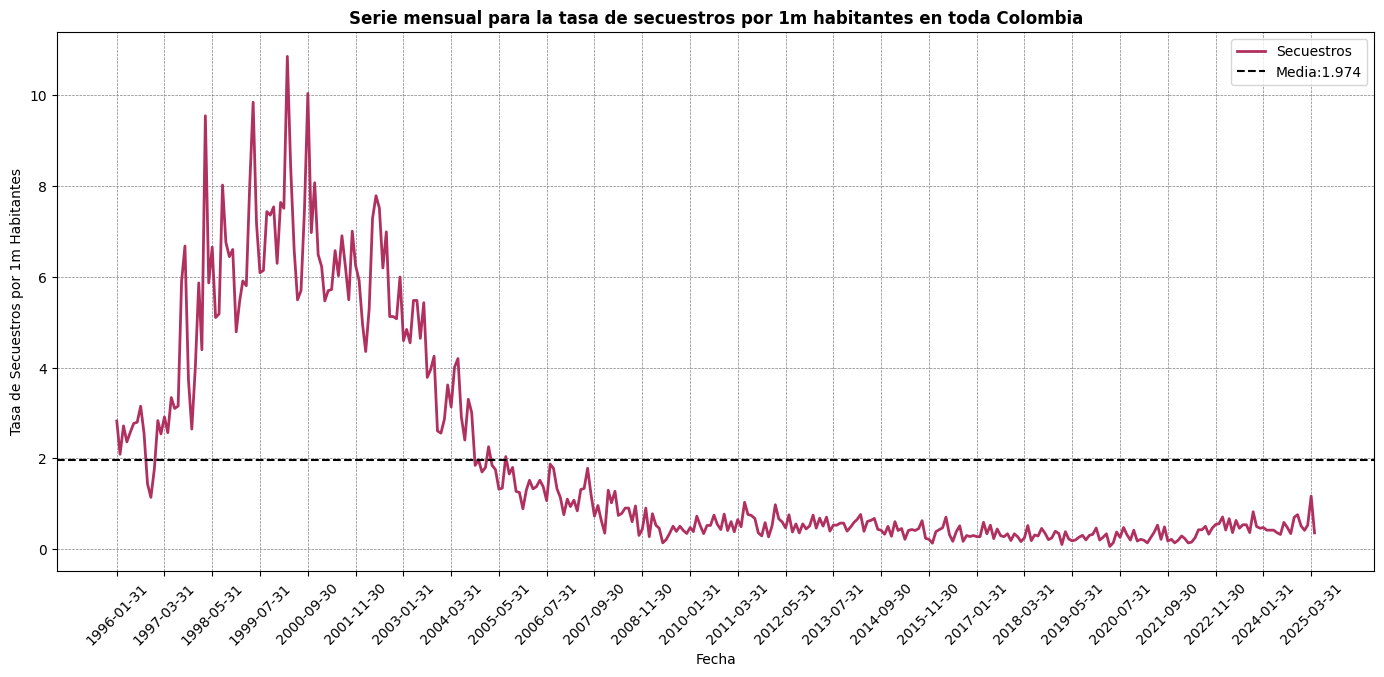

In [24]:
mean = serie_colombia_mensual['Tasa_100k'].mean()

plt.figure(figsize=(17, 7))    
plt.plot(serie_colombia_mensual['Fecha'], serie_colombia_mensual['Tasa_100k'] ,label="Secuestros", 
         linewidth=2 , color='#B03060')
plt.axhline(mean, color='black', linestyle='--', label=f'Media:{round(mean,3)}')
cuartiles_a_mostrar = serie_colombia_mensual['Fecha'][::14]
plt.xticks(cuartiles_a_mostrar, rotation=45)
plt.xlabel('Fecha')
plt.ylabel('Tasa de Secuestros por 1m Habitantes')
plt.title('Serie mensual para la tasa de secuestros por 1m habitantes en toda Colombia' , weight='bold')
plt.grid(True, color='gray', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

La serie de la tasa mensual de secuestros por millón de habitantes refleja con claridad el pulso de la violencia en Colombia: entre 1998 y 2001 se alcanzan los máximos, con picos de más de 10 secuestros por millón al mes. A partir de 2002 la curva desciende rápidamente y se estabiliza por debajo de 2 por millón desde 2007 hasta 2021, mostrando una drástica reducción en términos relativos.

Desde 2022 hay un ligero repunte que lleva la tasa de nuevo por encima de 0.5–1 por millón, señalando episodios puntuales de reactivación del secuestro en disidencias y nuevos grupos armados o grupos armados. En promedio, la tasa histórica se sitúa cerca de 2 secuestros por millón, pero el perfil de la curva subraya cómo los niveles de finales de los 90–2000 no tienen parangón en las últimas dos décadas.  


## Analisis Geografico mas detallado 

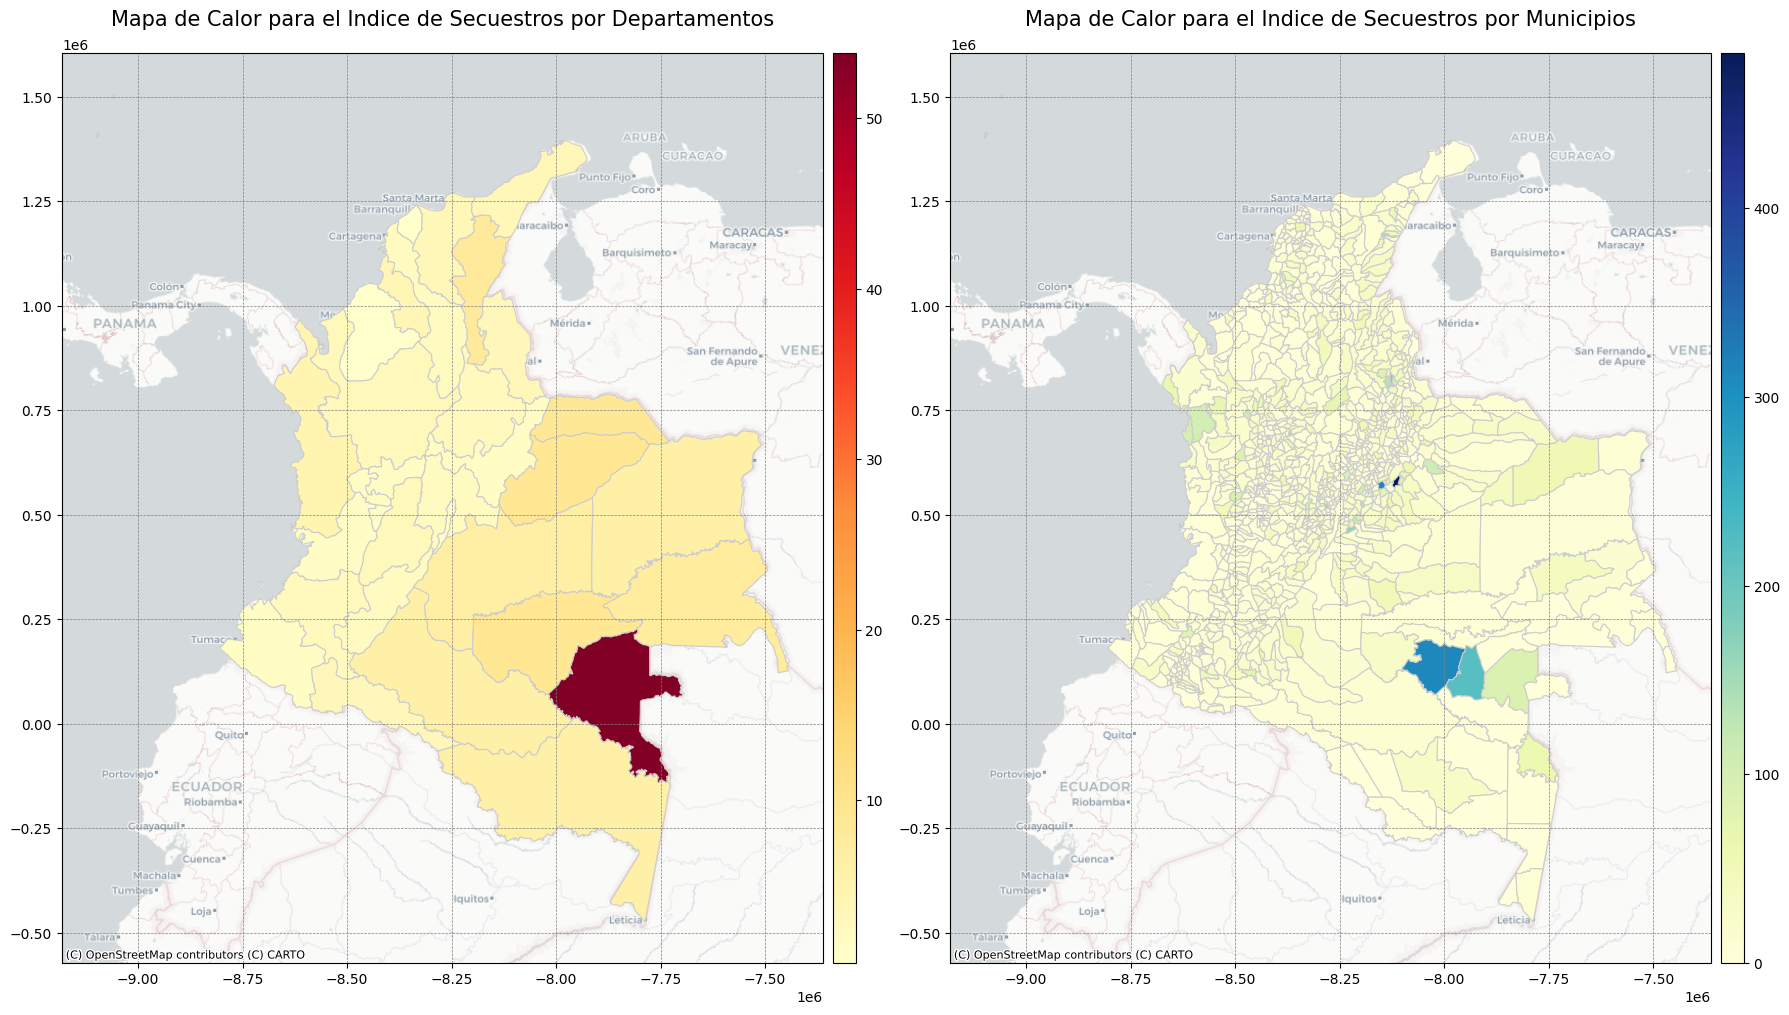

In [25]:
gdf_dept = gpd.read_file("C:\\Users\\alejo\\OneDrive\\Escritorio\\Universidaad\\Maestria Inteligencia de negocios\\Segundo Semestre\\Seminario Programacion\\Proyecto 1\\Datos\\Colombia.json")
gdf_muni = gpd.read_file('C:\\Users\\alejo\OneDrive\\Escritorio\\Universidaad\\Maestria Inteligencia de negocios\\Segundo Semestre\\Seminario Programacion\\Proyecto 1\\Datos\\Colombia_municipios.geojson')

## Geo dataframe por departamento
departamento_total_casos = (departamentos_anual.groupby(['DEPARTAMENTO', 'COD_DEPTO'])
    .agg({'Tasa_100k': 'mean','TOTAL': 'sum'}).reset_index())

gdf_dept['DPTO'] = gdf_dept['DPTO'].astype(int)
departamento_total_casos['DPTO'] = departamento_total_casos['COD_DEPTO'].astype(int)
gdf_dept1 = gdf_dept.merge(departamento_total_casos[['DPTO', 'Tasa_100k' , 'TOTAL']], on='DPTO' ,how='left' ,suffixes=('','_agg'))

## Geo dataframe por municipio
municipios_total_casos = (municipios_anual.groupby(['MUNICIPIO', 'COD_DEPTO'])
    .agg({'Tasa_100k': 'mean','TOTAL': 'sum'}).reset_index())
gdf_muni['MUNICIPIO'] = gdf_muni['nombre_mpi'].astype(str)
municipios_total_casos['MUNICIPIO'] = municipios_total_casos['MUNICIPIO'] .astype(str)
gdf_muni1 = gdf_muni.merge(municipios_total_casos[['MUNICIPIO', 'Tasa_100k' , 'TOTAL']], on='MUNICIPIO' ,how='left' ,suffixes=('','_agg')).drop(columns=['geo_point_2d',])
gdf_muni1[['Tasa_100k' , 'TOTAL']] = gdf_muni1[['Tasa_100k' , 'TOTAL']].fillna(0)

gdf_dept1 = gdf_dept1.to_crs(epsg=3857)
gdf_muni1 = gdf_muni1.to_crs(epsg=3857)

## Mapa
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))

divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes("right", size="3%", pad=0.1)

gdf_dept1.plot(column='Tasa_100k',cmap='YlOrRd',linewidth=0.8,edgecolor='0.8',ax=ax1,legend=True,cax=cax1)

ctx.add_basemap(ax1, source=ctx.providers.CartoDB.Positron)
ax1.grid(True, color='gray', linestyle='--', linewidth=0.5)
ax1.set_title("Mapa de Calor para el Indice de Secuestros por Departamentos", fontsize=15, pad=20)

divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes("right", size="3%", pad=0.1)

gdf_muni1.plot(column='Tasa_100k',cmap='YlGnBu',linewidth=0.8,edgecolor='0.8', ax=ax2,legend=True,cax=cax2)

ctx.add_basemap(ax2, source=ctx.providers.CartoDB.Positron)
ax2.grid(True, color='gray', linestyle='--', linewidth=0.5)
ax2.set_title("Mapa de Calor para el Indice de Secuestros por Municipios", fontsize=15, pad=20)

plt.tight_layout()
plt.show()


La comparación entre el mapa del indice creado con el de los valores absolutos (ver script 1) revela cómo la métrica elegida altera por completo la interpretación espacial:

- **Valores absolutos** (previamente analizado): Antioquia y Valle del Cauca aparecen en rojo intenso, pues concentran el mayor número bruto de secuestros. Bogotá D.C. y Meta también destacan, reflejando los grandes volúmenes atribuibles a su tamaño poblacional y extensión territorial.

- **Índice relativo** (análisis actual): al estandarizar por millón de habitantes, los focos se desplazan claramente hacia los Llanos Orientales y la zona sur del pais, estos territorios como Vaupés, Guaviare y Caquetá, eran famosos en los 90 por la presencia de las FARC y su condición de “perdida territorial”. Estas regiones superan los 50 secuestros por millón, mientras que departamentos como Antioquia o Valle del Cauca aparecen en tonos muy pálidos pese a su alto conteo absoluto. Esto principalmente porque en los llanos se secuestraban a mas personas teniendo en cuenta la poblacion.   


El mapa absoluto muestra "dónde sucedieron más secuestros", mientras que el índice revela "dónde el riesgo por habitante fue más crítico" y en donde se concentaron la mayor parte de la violencia en el pais.  


***
# 4. Analisis de los secuestros con la Presencia de Grupos Armados
***

### Analizar las acciones belicas registradas, para limpiar estas bases usaremos una de las funciones creada en el script de apoyo `construccion_bases_series.py`

In [28]:
acciones_belicas = pd.read_csv('C:\\Users\\alejo\\OneDrive\\Escritorio\\Universidaad\\Maestria Inteligencia de negocios\\Segundo Semestre\\Seminario Programacion\\Proyecto 1\\Datos\\Eventos_de_Violencia_del_Conflicto_Armado_Acciones Bélicas.csv')

lista = ['Año' , 'Mes', 'Día' , 'Código DANE de Municipio' , 'Municipio', 'Departamento' ,'Grupo Armado 1', 'Grupo Armado 2' ,'Total Combatientes', 'Total de Víctimas del Caso' ,'latitud-longitud']
acciones_belicas_depurado , acciones_belicas_geo = depurar_base(acciones_belicas, lista)
acciones_belicas_depurado.head(5)

,Código DANE de Municipio,Municipio,Departamento,Grupo Armado 1,Grupo Armado 2,Total Combatientes,Total de Víctimas del Caso,latitud-longitud,fecha
0,27073,BAGADO,CHOCO,AGENTE DEL ESTADO,GUERRILLA,0,1,POINT (-76.197969065 5.503119772),2006-03-12
3,41676,SANTA MARIA,HUILA,GUERRILLA,GRUPO PARAMILITAR,6,6,POINT (-75.587213 2.937628),1966-01-31
4,85010,AGUAZUL,CASANARE,AGENTE DEL ESTADO,GUERRILLA,2,2,POINT (-72.45852372 5.100675341),1996-02-17
5,EXVEN,FRONTERA VENEZUELA,EXTERIOR,AGENTE EXTRANJERO,GUERRILLA,2,2,POINT (-72.73 9.1),1996-02-17
6,20238,EL COPEY,CESAR,AGENTE DEL ESTADO,GUERRILLA,1,1,POINT (-73.91282064 10.19995356),1996-02-17


### Unir base a las bases que hemos trabajado 

In [29]:
excluir = ['BANDOLERISMO', 'DESCONOCIDO', 'OTRO ¿CUÁL?' , 'AGENTE EXTRANJERO' , 'GRUPO ARMADO NO DIRIMIDO']

acciones_belicas_depurado = acciones_belicas_depurado[~acciones_belicas_depurado['Grupo Armado 2'].isin(excluir)]
acciones_belicas_depurado['fecha'] = pd.to_datetime(acciones_belicas_depurado['fecha'])

# Extraer año-mes para agrupar por mes
acciones_belicas_depurado['year_month'] = acciones_belicas_depurado['fecha'].dt.to_period('Y')

# Crea dummies de los grupos
dummies_grupo = pd.get_dummies(acciones_belicas_depurado['Grupo Armado 2'], prefix='G2')
dummies_grupo1 = pd.get_dummies(acciones_belicas_depurado['Grupo Armado 1'], prefix='G1')
acciones_belicas_depurado2 = pd.concat([acciones_belicas_depurado, dummies_grupo , dummies_grupo1], axis=1)

cols_sum = list(dummies_grupo.columns) + list(dummies_grupo1.columns)  + ['Total Combatientes', 'Total de Víctimas del Caso'] 

acciones_belicas_depurado2 = (acciones_belicas_depurado2.groupby(['Municipio', 'year_month' , 'Código DANE de Municipio'])[cols_sum]
    .sum().reset_index())

acciones_belicas_depurado2['year_month'] = acciones_belicas_depurado2['year_month'].dt.to_timestamp()
acciones_belicas_depurado2['AÑO'] = acciones_belicas_depurado2['year_month'].dt.year.astype(int)
acciones_belicas_depurado2 = acciones_belicas_depurado2.rename(columns={'Municipio': 'MUNICIPIO'})

## Hacer el Merge con el df anual por municipio de secuestros 
municipios_anual_crimen = municipios_anual.merge(acciones_belicas_depurado2[cols_sum + ['MUNICIPIO' ,'AÑO']], on=['MUNICIPIO','AÑO'] ,how='left' ,suffixes=('','_agg'))
municipios_anual_crimen = municipios_anual_crimen.fillna(0)
municipios_anual_crimen 

,AÑO,COD_DEPTO,DEPARTAMENTO,COD_MUNI,MUNICIPIO,N_SIMPLE,N_EXTORSIVO,TOTAL,Población,Tasa_100k,...,G1_BANDOLERISMO,G1_CRIMEN ORGANIZADO,G1_DESCONOCIDO,G1_GRUPO ARMADO NO IDENTIFICADO,G1_GRUPO PARAMILITAR,G1_GRUPO POSDESMOVILIZACIÓN,G1_GUERRILLA,G1_OTRO ¿CUÁL?,Total Combatientes,Total de Víctimas del Caso
0,1996,5,ANTIOQUIA,5001,MEDELLIN,8,73,81,1787831,4.530630,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,12.0,13.0
1,1996,5,ANTIOQUIA,5002,ABEJORRAL,0,2,2,25094,7.970033,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,5.0
2,1996,5,ANTIOQUIA,5030,AMAGA,0,2,2,25201,7.936193,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1996,5,ANTIOQUIA,5031,AMALFI,1,1,2,20966,9.539254,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1996,5,ANTIOQUIA,5034,ANDES,0,2,2,41359,4.835707,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6764,2025,81,ARAUCA,81065,ARAUQUITA,4,0,4,64172,6.233248,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6765,2025,81,ARAUCA,81736,SARAVENA,4,0,4,65754,6.083280,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6766,2025,81,ARAUCA,81794,TAME,5,0,5,54772,9.128752,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6767,2025,85,CASANARE,85001,YOPAL,0,1,1,196758,0.508239,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Graficar la cantidad de incidentes de Acciones Belicas en el Pais

Debido a que hay muchos registros por separado, graficar cada uno individualmente en los mapas seria poco vistoso. Por eso vamos a usar DBSCAN para agrupar un un buffer de kilometros la cantidad de acciones belicas (y en un futuro las demas variables de conflicto) en conglomerados donde los grupos mas garndes se centraran en las zonas donde mas hubo accion por parte de los diferentes grupos armados 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


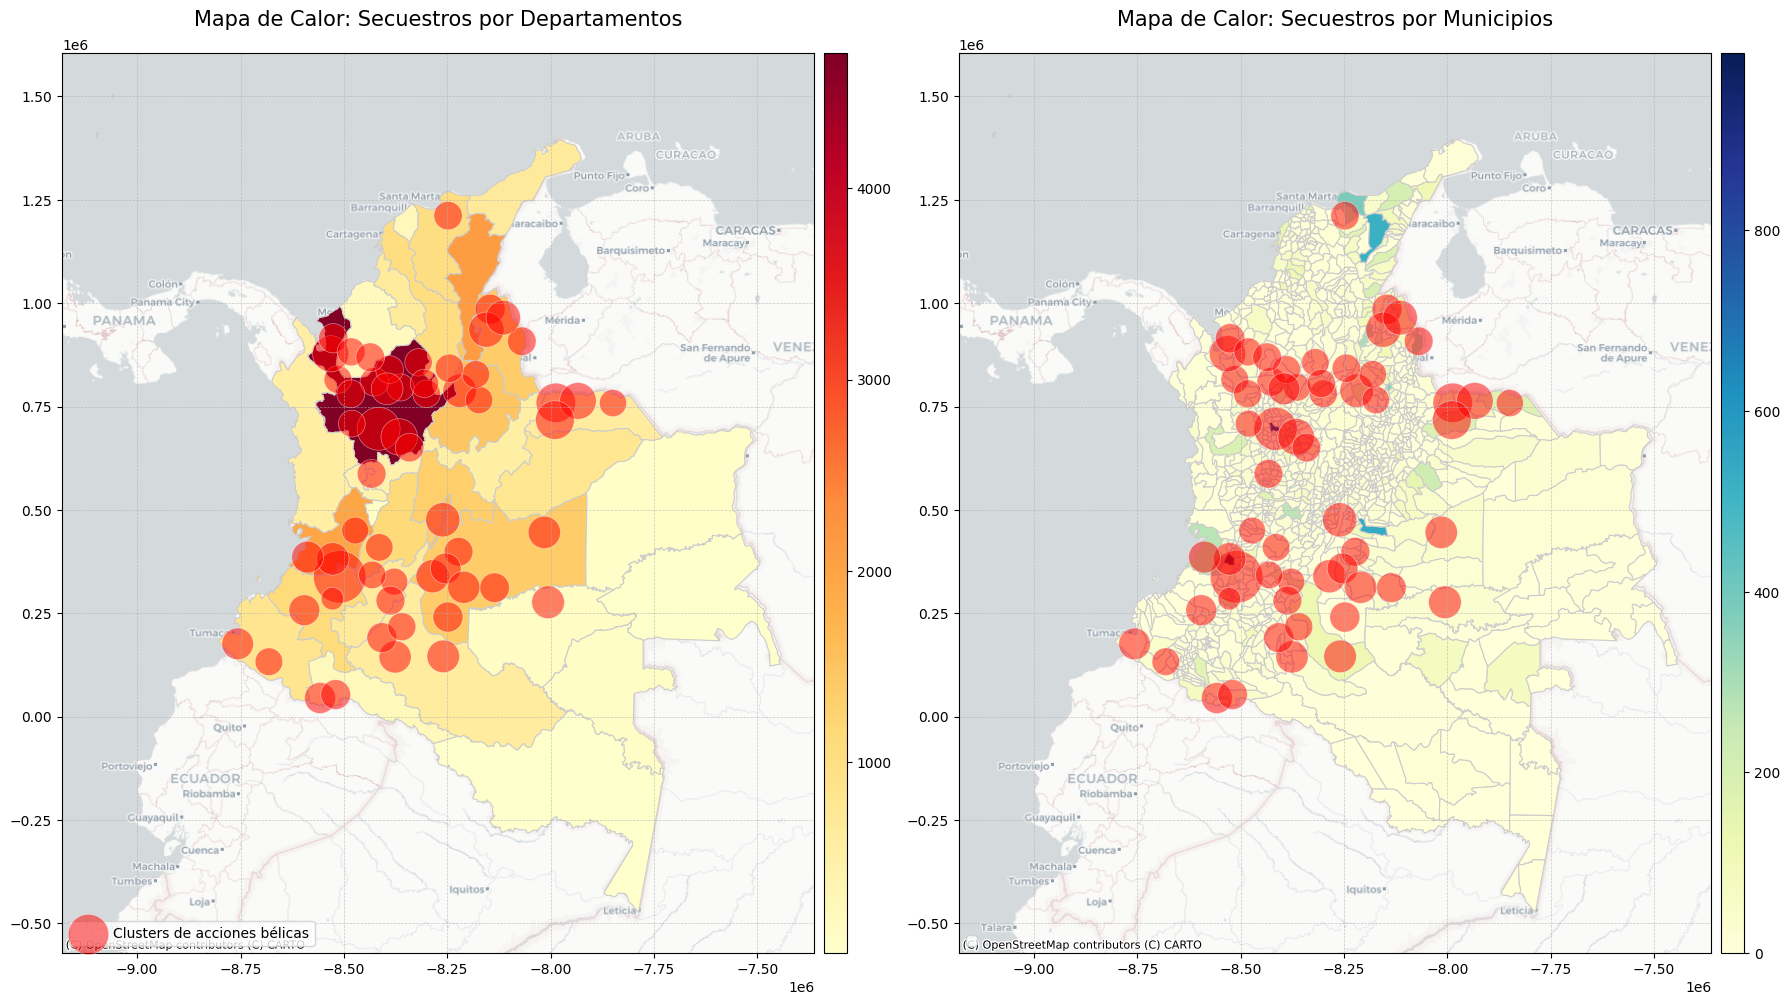

In [242]:
# Pasar todos los sistemas de coordenadas a uno igual 
gdf_dept1 = gdf_dept1.to_crs(epsg=3857)
gdf_muni1 = gdf_muni1.to_crs(epsg=3857)
acciones_belicas_geo = acciones_belicas_geo.to_crs(epsg=3857) # Usamos la base geografica que creamos donde aun no agrupamos por municipio. Es decir 
                                                              # esta base cada fila aun son eventos por separado en suelto, para asi poder graficarlos como burbujas

# Debido a que tenemos muchos puntos de violencia usaremos DBSCAN para generar clusteres con violencia 
coords = np.vstack([acciones_belicas_geo.geometry.x,acciones_belicas_geo.geometry.y]).T

db = DBSCAN(eps=15000, min_samples=150, metric='euclidean').fit(coords) # El criterio sera en un radio de 15km y con minimo 150 casos de violencia 
acciones_belicas_geo['cluster'] = db.labels_

cl = acciones_belicas_geo[acciones_belicas_geo.cluster >= 0]

clusters = (cl.dissolve(by='cluster').geometry.centroid.to_frame(name='geometry'))
counts = cl.groupby('cluster').size().rename('count')
clusters = clusters.join(counts, on='cluster')
clusters = gpd.GeoDataFrame(clusters, geometry='geometry', crs=acciones_belicas_geo.crs)

# Garantizamos que todos los clusters queden en la region geografica de Colombia 
xmin, ymin, xmax, ymax = gdf_muni1.total_bounds
clusters_in = clusters[
    (clusters.geometry.x >= xmin) & (clusters.geometry.x <= xmax) &
    (clusters.geometry.y >= ymin) & (clusters.geometry.y <= ymax)]

######## GRAFICA ############# 

clusters_in['size'] = np.sqrt(clusters_in['count']) * 30  

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))

## Grafico para los Departamentos 
divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes("right", size="3%", pad=0.1)

gdf_dept1.plot(column='TOTAL',cmap='YlOrRd',linewidth=0.8,
    edgecolor='0.8',ax=ax1,legend=True,cax=cax1)
ctx.add_basemap(ax1, source=ctx.providers.CartoDB.Positron)
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax1.set_title("Mapa de Calor: Secuestros por Departamentos", fontsize=15, pad=20)

## Superponer los clusters encontrados con DBSCAN
clusters_in.plot(ax=ax1,markersize=clusters_in['size'],alpha=0.5,
    color='red',edgecolor='white',linewidth=0.5,
    label='Clusters de acciones bélicas')
ax1.legend(loc='lower left')

## Grafico para los Municipios
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes("right", size="3%", pad=0.1)

gdf_muni1.plot(column='TOTAL',cmap='YlGnBu',
    linewidth=0.8,edgecolor='0.8',ax=ax2,
    legend=True,cax=cax2)
ctx.add_basemap(ax2, source=ctx.providers.CartoDB.Positron)
ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax2.set_title("Mapa de Calor: Secuestros por Municipios", fontsize=15, pad=20)

## Superponer los clusters encontrados con DBSCAN
clusters_in.plot(ax=ax2,markersize=clusters_in['size'],alpha=0.5,
    color='red',edgecolor='white',linewidth=0.5)
ax2.legend(loc='lower left')


plt.tight_layout()
plt.show()

En este segundo mapa, las burbujas rojas, las cuales representan acciones bélicas de guerrilla y conflictos armados, se concentran en los mismos departamentos con mayor número de secuestros absolutos (Antioquia, Valle del Cauca, Santander, Meta), lo que refuerza la asociación directa entre presencia guerrillera y volumen de secuestros.  

A nivel municipal la distribución es parecida, con burbujas grandes en cabeceras y departamentos que tienen la mayor cantidad de secuestros, aunque la correlación no es tan perfecta: algunos municipios dentro de departamentos “calientes” muestran menos actividad guerrillera de la esperada, y viceversa, lo que sugiere dinámicas locales y diferencias en la eficacia de control territorial.  
 


## Analizar Asesinatos Selectivos por grupos armados como segunda proxy de la cantidad Presencia de grupos armados

In [30]:
asses = pd.read_csv('C:\\Users\\alejo\\OneDrive\\Escritorio\\Universidaad\\Maestria Inteligencia de negocios\\Segundo Semestre\\Seminario Programacion\\Proyecto 1\\Datos\\Eventos_de_Violencia_del_Conflicto_Armado_Asesinatos.csv')
lista = ['Año', 'Mes', 'Día' , 'Código DANE de Municipio', 'Municipio', 'Departamento'  ,'latitud-longitud' ]
asses_depurado , asses_geo = depurar_base(asses, lista)
asses_depurado.head()

C:\Users\alejo\AppData\Local\Temp\ipykernel_4176\1063770319.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  asses = pd.read_csv('C:\\Users\\alejo\\OneDrive\\Escritorio\\Universidaad\\Maestria Inteligencia de negocios\\Segundo Semestre\\Seminario Programacion\\Proyecto 1\\Datos\\Eventos_de_Violencia_del_Conflicto_Armado_Asesinatos.csv')


,Código DANE de Municipio,Municipio,Departamento,latitud-longitud,fecha
0,25290,FUSAGASUGA,CUNDINAMARCA,POINT (-74.388591139 4.323534028),2003-10-27
1,25290,FUSAGASUGA,CUNDINAMARCA,POINT (-74.38859114 4.323534028),2003-11-24
2,25290,FUSAGASUGA,CUNDINAMARCA,POINT (-74.38859114 4.323534028),2003-11-24
3,25290,FUSAGASUGA,CUNDINAMARCA,POINT (-74.38859114 4.323534028),2003-11-24
4,25290,FUSAGASUGA,CUNDINAMARCA,POINT (-74.38859114 4.323534028),2004-01-01


### Agrupar en la base de secuestros con las nuevas columnas de Acciones Belicas 

In [31]:
asses_depurado['fecha'] = pd.to_datetime(asses_depurado['fecha'])
asses_depurado['AÑO'] = asses_depurado['fecha'].dt.year
asses_depurado = (asses_depurado.groupby(['Código DANE de Municipio',
        'Municipio','Departamento','AÑO'], as_index=False).size().rename(columns={'size': 'Asesinatos Selectivos'}))
asses_depurado = asses_depurado.rename(columns={'Municipio': 'MUNICIPIO'})
asses_depurado

municipios_anual_asesinatos = municipios_anual_crimen.merge(asses_depurado[['MUNICIPIO' ,'AÑO' ,'Asesinatos Selectivos']], on=['MUNICIPIO','AÑO'] ,how='left' ,suffixes=('','_agg'))
municipios_anual_asesinatos = municipios_anual_asesinatos.fillna(0)
municipios_anual_asesinatos.shape  # Podemos ver que tenemos una columna extra que corresponde a los Asesinatos Selectivos

(9768, 31)

### Graficar la cantidad de asesinatos selctivos en el Pais

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


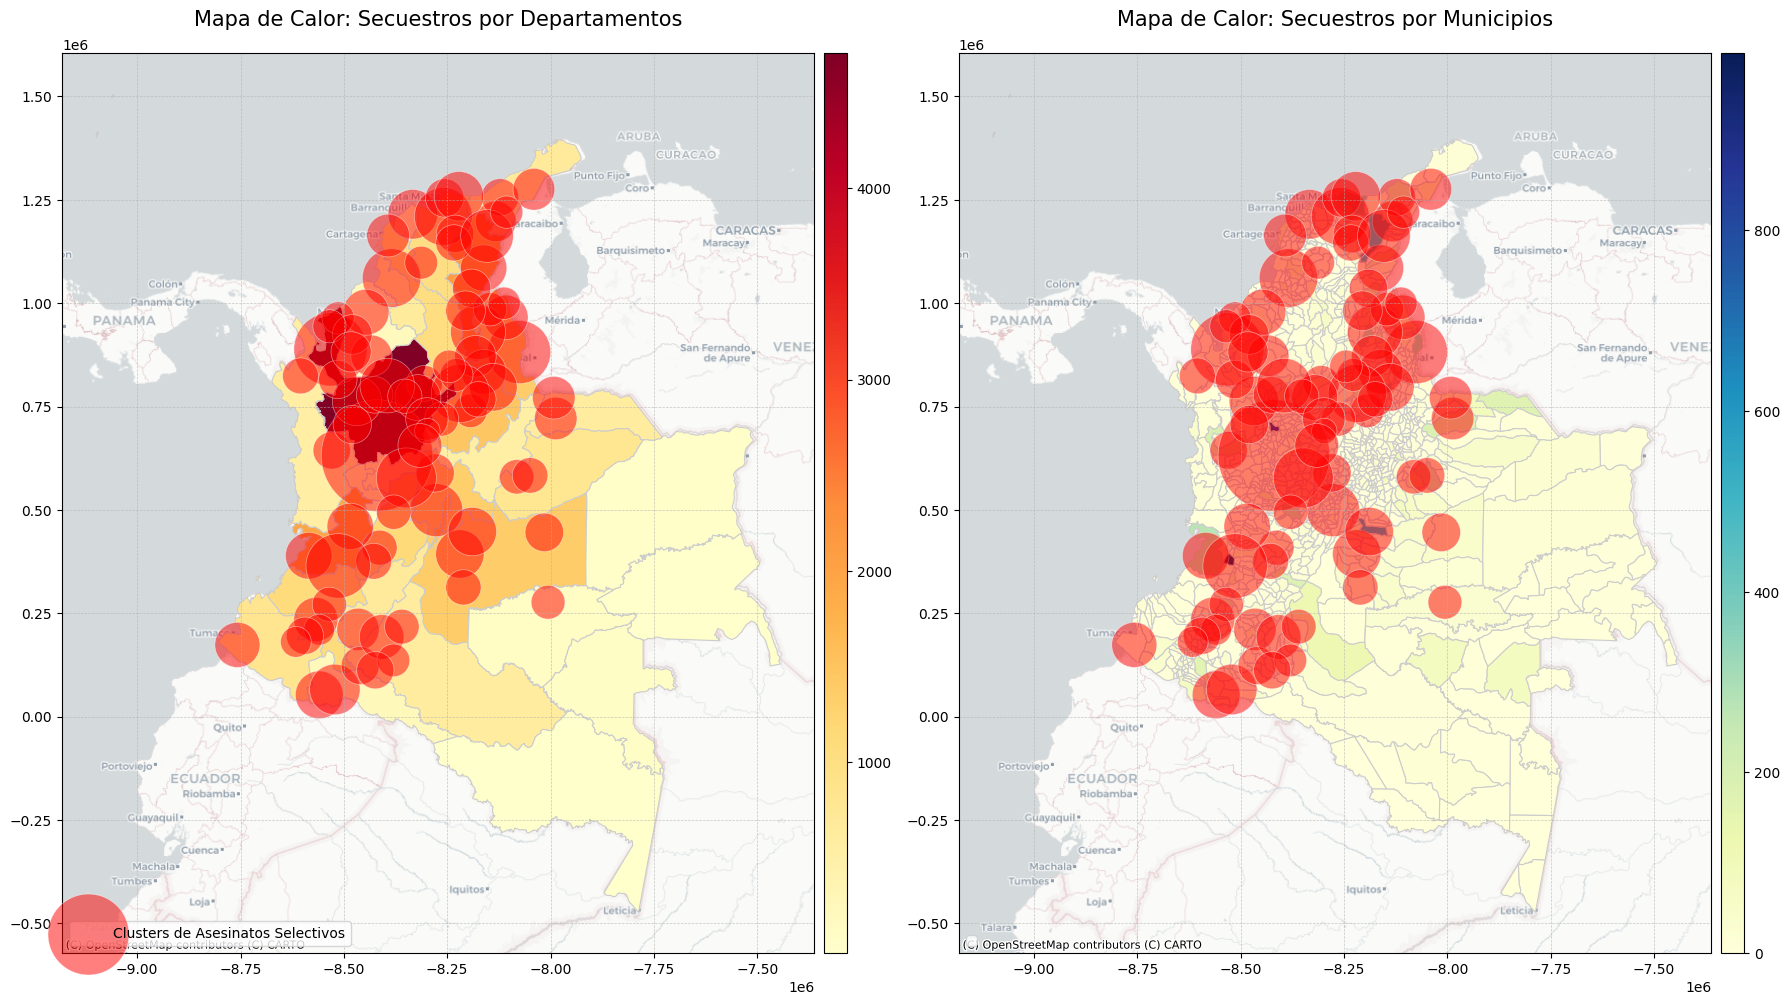

In [258]:
gdf_dept1 = gdf_dept1.to_crs(epsg=3857)
gdf_muni1 = gdf_muni1.to_crs(epsg=3857)
asses_geo = asses_geo.to_crs(epsg=3857)

# Debido a que tenemos muchos puntos de violencia usaremos DBSCAN para generar clusteres con violencia 
coords = np.vstack([asses_geo.geometry.x,asses_geo.geometry.y]).T

db = DBSCAN(eps=15000, min_samples=320, metric='euclidean').fit(coords) # El criterio sera en un radio de 15km y con minimo 320 casos de asesinatos selectivos 
asses_geo['cluster'] = db.labels_

cl = asses_geo[asses_geo.cluster >= 0]

clusters = (cl.dissolve(by='cluster').geometry.centroid.to_frame(name='geometry'))
counts = cl.groupby('cluster').size().rename('count')
clusters = clusters.join(counts, on='cluster')
clusters = gpd.GeoDataFrame(clusters, geometry='geometry', crs=asses_geo.crs)

# Garantizamos que todos los clusters queden en la region geografica de Colombia 
xmin, ymin, xmax, ymax = gdf_muni1.total_bounds
clusters_in = clusters[
    (clusters.geometry.x >= xmin) & (clusters.geometry.x <= xmax) &
    (clusters.geometry.y >= ymin) & (clusters.geometry.y <= ymax)]

######## GRAFICA ############# 

clusters_in['size'] = np.sqrt(clusters_in['count']) * 30  

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))

## Grafico para los Departamentos 
divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes("right", size="3%", pad=0.1)

gdf_dept1.plot(column='TOTAL',cmap='YlOrRd',linewidth=0.8,
    edgecolor='0.8',ax=ax1,legend=True,cax=cax1)
ctx.add_basemap(ax1, source=ctx.providers.CartoDB.Positron)
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax1.set_title("Mapa de Calor: Secuestros por Departamentos", fontsize=15, pad=20)

## Superponer los clusters encontrados con DBSCAN
clusters_in.plot(ax=ax1,markersize=clusters_in['size'],alpha=0.5,
    color='red',edgecolor='white',linewidth=0.5,
    label='Clusters de Asesinatos Selectivos')
ax1.legend(loc='lower left')

## Grafico para los Municipios
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes("right", size="3%", pad=0.1)

gdf_muni1.plot(column='TOTAL',cmap='YlGnBu',
    linewidth=0.8,edgecolor='0.8',ax=ax2,
    legend=True,cax=cax2)
ctx.add_basemap(ax2, source=ctx.providers.CartoDB.Positron)
ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax2.set_title("Mapa de Calor: Secuestros por Municipios", fontsize=15, pad=20)

## Superponer los clusters encontrados con DBSCAN
clusters_in.plot(ax=ax2,markersize=clusters_in['size'],alpha=0.5,
    color='red',edgecolor='white',linewidth=0.5)
ax2.legend(loc='lower left')


plt.tight_layout()
plt.show()

Este mapa de “asesinatos selectivos” muestra un patrón más disperso que los actos belicos, pero refuerza la alta vinculación entre violencia armada y los secuestros de forma absoluta. En los departamentos, las burbujas más grandes vuelven a concentrarse en Antioquia (junto a Valle del Cauca y Santander), evidenciando que allí la intensidad de los asesinatos selectivos (lo cual es una buena proxy de la cantidad de grupos armados) fue directamente proporcional al volumen de secuestros.  

A nivel municipal la correlación es aún más clara: cabeceras como Medellín, Cali, Florencia y la zona del pacifico, aparecen con grandes círculos rojos, alineándose con los municipios que también registraban altos secuestros. Sin embargo, la presencia de burbujas distribuidas por todo el país, incluso en regiones con pocos secuestros, indica que los asesinatos selectivos fueron una forma de violencia más extendida, lo que “ensucia” la métrica al incluir focos de conflicto no necesariamente ligados a las dinámicas de secuestro.  


## Analizar Masacres por grupos armados como tercera proxy de la cantidad  de grupos armado

Un problema con los asesinatos selectivos es que podian ocurrir en cualquier parte del pais y no significa que justo en esa zona haya una presencia de grupos armados, por eso consideramos que el primer mapa (acciones belicas) es una proxy mas directa de en donde se concnetraba la guerrilla ty grupos paramilitares. Sin embargo, algo por lo que se caracterizo esta epoca manchada de violencia fueron las masacres. Con esta proxy, mas concentrada y con menos casos consideramos que sera mas facil ubicar verdaderamente en donde se movian los grupos al margen de la ley en el pais

In [32]:
masacres = pd.read_csv('C:\\Users\\alejo\\OneDrive\\Escritorio\\Universidaad\\Maestria Inteligencia de negocios\\Segundo Semestre\\Seminario Programacion\\Proyecto 1\\Datos\\Eventos_de_Violencia_del_Conflicto_Armado_Masacres.csv')
lista = ['Año', 'Mes', 'Día' , 'Código DANE de Municipio', 'Municipio', 'Departamento'  ,'Presunto Responsable','Total de Víctimas del Caso' ,'latitud-longitud']
masacres_depurado , masacres_geo = depurar_base(masacres, lista)
masacres_depurado.head(10)


,Código DANE de Municipio,Municipio,Departamento,Presunto Responsable,Total de Víctimas del Caso,latitud-longitud,fecha
0,25530,PARATEBUENO,CUNDINAMARCA,GRUPO PARAMILITAR,5,POINT (-73.241661397 4.368158959),1998-01-25
1,27361,ISTMINA,CHOCO,GRUPO POSDESMOVILIZACIÓN,4,POINT (-77.00090737 4.586818665),2007-10-17
2,44430,MAICAO,LA GUAJIRA,GRUPO PARAMILITAR,4,POINT (-72.241861 11.378319),2005-12-07
3,44430,MAICAO,LA GUAJIRA,GRUPO PARAMILITAR,4,POINT (-72.241861 11.378319),2000-06-18
4,44430,MAICAO,LA GUAJIRA,GRUPO PARAMILITAR,4,POINT (-72.29500818 11.38157764),2002-06-02
5,44430,MAICAO,LA GUAJIRA,GRUPO PARAMILITAR,4,POINT (-72.241861 11.378319),2002-08-06
6,47001,SANTA MARTA,MAGDALENA,GRUPO PARAMILITAR,5,POINT (-73.88527855 11.12189436),1988-07-12
7,47001,SANTA MARTA,MAGDALENA,GRUPO PARAMILITAR,4,POINT (-73.88527855 11.12189436),2002-03-07
8,47189,CIENAGA,MAGDALENA,GRUPO PARAMILITAR,5,POINT (-74.02404322 10.76964718),1988-07-12
9,47268,EL RETEN,MAGDALENA,GRUPO PARAMILITAR,4,POINT (-74.268412 10.610445),1995-05-21


In [33]:
excluir = ['BANDOLERISMO', 'DESCONOCIDO', 'OTRO ¿CUÁL?' , 'AGENTE EXTRANJERO' , 'GRUPO ARMADO NO DIRIMIDO', 'GRUPO ARMADO NO IDENTIFICADO', 'AGENTE DEL ESTADO']

masacres_depurado = masacres_depurado[~masacres_depurado['Presunto Responsable'].isin(excluir)]
masacres_depurado['fecha'] = pd.to_datetime(masacres_depurado['fecha'])

# Extraer año-mes para agrupar por mes
masacres_depurado['year_month'] = masacres_depurado['fecha'].dt.to_period('Y')

# Crea dummies de los grupos
dummies_grupo = pd.get_dummies(masacres_depurado['Presunto Responsable'], prefix='PR')
masacres_depurado2 = pd.concat([masacres_depurado, dummies_grupo ], axis=1)

cols_sum = list(dummies_grupo.columns)  + ['Total de Víctimas del Caso'] 

masacres_depurado2 = (masacres_depurado2.groupby(['Municipio', 'year_month' , 'Código DANE de Municipio'])[cols_sum]
    .sum().reset_index())

masacres_depurado2['year_month'] = masacres_depurado2['year_month'].dt.to_timestamp()
masacres_depurado2['AÑO'] = masacres_depurado2['year_month'].dt.year.astype(int)
masacres_depurado2 = masacres_depurado2.rename(columns={'Municipio': 'MUNICIPIO' , 'Total de Víctimas del Caso': 'Victimas Masacre'})

## Hacer el Merge con el df anual por municipio de secuestros 
municipios_anual_guerr = municipios_anual_asesinatos.merge(masacres_depurado2[list(dummies_grupo.columns) + ['MUNICIPIO' ,'AÑO' ,'Victimas Masacre']], on=['MUNICIPIO','AÑO'] ,how='left' ,suffixes=('','_agg'))
municipios_anual_guerr = municipios_anual_guerr.fillna(0)
municipios_anual_guerr 

,AÑO,COD_DEPTO,DEPARTAMENTO,COD_MUNI,MUNICIPIO,N_SIMPLE,N_EXTORSIVO,TOTAL,Población,Tasa_100k,...,G1_OTRO ¿CUÁL?,Total Combatientes,Total de Víctimas del Caso,Asesinatos Selectivos,PR_AGENTE DEL ESTADO - GRUPO PARAMILITAR,PR_CRIMEN ORGANIZADO,PR_GRUPO PARAMILITAR,PR_GRUPO POSDESMOVILIZACIÓN,PR_GUERRILLA,Victimas Masacre
0,1996,5,ANTIOQUIA,5001,MEDELLIN,8,73,81,1787831,4.530630,...,0.0,12.0,13.0,1036.0,0.0,0.0,4.0,0.0,0.0,37.0
1,1996,5,ANTIOQUIA,5002,ABEJORRAL,0,2,2,25094,7.970033,...,0.0,5.0,5.0,4.0,0.0,0.0,1.0,0.0,0.0,4.0
2,1996,5,ANTIOQUIA,5030,AMAGA,0,2,2,25201,7.936193,...,0.0,0.0,0.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1996,5,ANTIOQUIA,5031,AMALFI,1,1,2,20966,9.539254,...,0.0,0.0,0.0,14.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1996,5,ANTIOQUIA,5034,ANDES,0,2,2,41359,4.835707,...,0.0,6.0,6.0,30.0,0.0,0.0,1.0,0.0,0.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9832,2025,81,ARAUCA,81065,ARAUQUITA,4,0,4,64172,6.233248,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9833,2025,81,ARAUCA,81736,SARAVENA,4,0,4,65754,6.083280,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9834,2025,81,ARAUCA,81794,TAME,5,0,5,54772,9.128752,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9835,2025,85,CASANARE,85001,YOPAL,0,1,1,196758,0.508239,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Como ya acabamos con las variables de violencia, sumemos la cantidad de grupos al margen de la ley que tenemos para reducir la dimensionalidad de la base 

In [34]:
base_sec_violen = municipios_anual_guerr.copy()

# Usemos expresiones regulares para seleccionar aquellas que creamos con G1_, G2_ o PR_
group_cols = [col for col in base_sec_violen.columns if re.match(r'^(G1|G2|PR)_', col)]

suffix_dict = defaultdict(list)
for col in group_cols:
    suffix = col.split('_', 1)[1]   
    suffix_dict[suffix].append(col)

# Hacemos la suma de cada variable dummy
for suf, cols in suffix_dict.items():
    base_sec_violen[suf] = base_sec_violen[cols].sum(axis=1)

# Eliminar las columas con G1_, G2_ y PR_
base_sec_violen = base_sec_violen.drop(columns=group_cols)
base_sec_violen = base_sec_violen.drop(columns=['AGENTE EXTRANJERO','BANDOLERISMO', 'DESCONOCIDO', 'OTRO ¿CUÁL?'])
base_sec_violen.head(10) ## Como podemos ver redujimos el numero de columnas agrupando la cantidad de personas en cada una de las actividades como un proxy de la grupos en cada municipio

,AÑO,COD_DEPTO,DEPARTAMENTO,COD_MUNI,MUNICIPIO,N_SIMPLE,N_EXTORSIVO,TOTAL,Población,Tasa_100k,...,Asesinatos Selectivos,Victimas Masacre,AGENTE DEL ESTADO,AGENTE DEL ESTADO - GUERRILLA,CRIMEN ORGANIZADO,GRUPO ARMADO NO IDENTIFICADO,GRUPO PARAMILITAR,GRUPO POSDESMOVILIZACIÓN,GUERRILLA,AGENTE DEL ESTADO - GRUPO PARAMILITAR
0,1996,5,ANTIOQUIA,5001,MEDELLIN,8,73,81,1787831,4.530630,...,1036.0,37.0,7.0,0.0,0.0,3.0,4.0,0.0,6.0,0.0
1,1996,5,ANTIOQUIA,5002,ABEJORRAL,0,2,2,25094,7.970033,...,4.0,4.0,5.0,0.0,0.0,0.0,1.0,0.0,5.0,0.0
2,1996,5,ANTIOQUIA,5030,AMAGA,0,2,2,25201,7.936193,...,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1996,5,ANTIOQUIA,5031,AMALFI,1,1,2,20966,9.539254,...,14.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1996,5,ANTIOQUIA,5034,ANDES,0,2,2,41359,4.835707,...,30.0,4.0,2.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0
5,1996,5,ANTIOQUIA,5038,ANGOSTURA,0,1,1,12845,7.785130,...,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,1996,5,ANTIOQUIA,5040,ANORI,1,0,1,14244,7.020500,...,7.0,0.0,12.0,0.0,0.0,0.0,0.0,0.0,12.0,0.0
7,1996,5,ANTIOQUIA,5042,SANTAFE DE ANTIOQUIA,2,10,12,21787,55.078717,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,1996,5,ANTIOQUIA,5045,APARTADO,1,7,8,71480,11.191942,...,383.0,41.0,10.0,0.0,0.0,2.0,8.0,0.0,14.0,0.0
9,1996,5,ANTIOQUIA,5086,BELMIRA,0,1,1,5855,17.079419,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Graficar la cantidad de masacres en el Pais

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


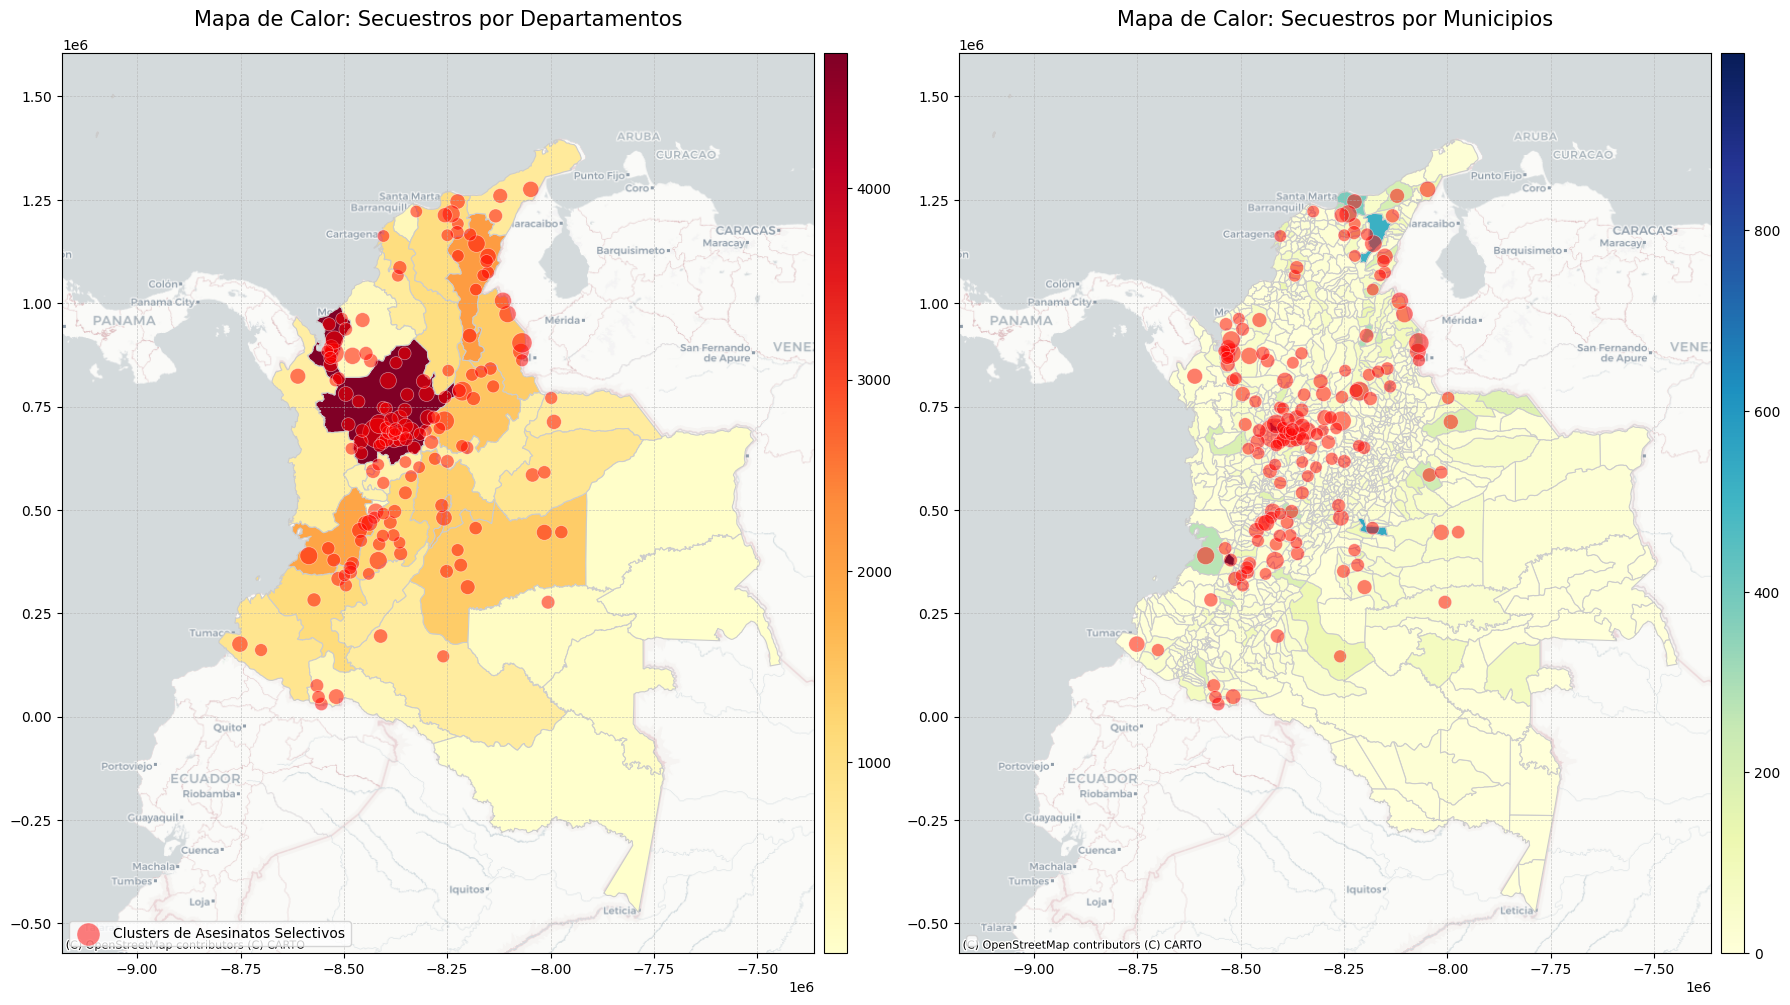

In [268]:
gdf_dept1 = gdf_dept1.to_crs(epsg=3857)
gdf_muni1 = gdf_muni1.to_crs(epsg=3857)
masacres_geo = masacres_geo.to_crs(epsg=3857)

# Debido a que tenemos muchos puntos de violencia usaremos DBSCAN para generar clusteres con violencia 
coords = np.vstack([masacres_geo.geometry.x,masacres_geo.geometry.y]).T

db = DBSCAN(eps=5000, min_samples=7, metric='euclidean').fit(coords) # El criterio sera en un radio de 15km y con minimo 320 casos de asesinatos selectivos 
masacres_geo['cluster'] = db.labels_

cl = masacres_geo[masacres_geo.cluster >= 0]

clusters = (cl.dissolve(by='cluster').geometry.centroid.to_frame(name='geometry'))
counts = cl.groupby('cluster').size().rename('count')
clusters = clusters.join(counts, on='cluster')
clusters = gpd.GeoDataFrame(clusters, geometry='geometry', crs=masacres_geo.crs)

# Garantizamos que todos los clusters queden en la region geografica de Colombia 
xmin, ymin, xmax, ymax = gdf_muni1.total_bounds
clusters_in = clusters[
    (clusters.geometry.x >= xmin) & (clusters.geometry.x <= xmax) &
    (clusters.geometry.y >= ymin) & (clusters.geometry.y <= ymax)]

######## GRAFICA ############# 

clusters_in['size'] = np.sqrt(clusters_in['count']) * 30  

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))

## Grafico para los Departamentos 
divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes("right", size="3%", pad=0.1)

gdf_dept1.plot(column='TOTAL',cmap='YlOrRd',linewidth=0.8,
    edgecolor='0.8',ax=ax1,legend=True,cax=cax1)
ctx.add_basemap(ax1, source=ctx.providers.CartoDB.Positron)
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax1.set_title("Mapa de Calor: Secuestros por Departamentos", fontsize=15, pad=20)

## Superponer los clusters encontrados con DBSCAN
clusters_in.plot(ax=ax1,markersize=clusters_in['size'],alpha=0.5,
    color='red',edgecolor='white',linewidth=0.5,
    label='Clusters de Asesinatos Selectivos')
ax1.legend(loc='lower left')

## Grafico para los Municipios
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes("right", size="3%", pad=0.1)

gdf_muni1.plot(column='TOTAL',cmap='YlGnBu',
    linewidth=0.8,edgecolor='0.8',ax=ax2,
    legend=True,cax=cax2)
ctx.add_basemap(ax2, source=ctx.providers.CartoDB.Positron)
ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax2.set_title("Mapa de Calor: Secuestros por Municipios", fontsize=15, pad=20)

## Superponer los clusters encontrados con DBSCAN
clusters_in.plot(ax=ax2,markersize=clusters_in['size'],alpha=0.5,
    color='red',edgecolor='white',linewidth=0.5)
ax2.legend(loc='lower left')


plt.tight_layout()
plt.show()


A diferencia de los asesinatos selectivos (que podían dispersarse por todo el territorio), las masacres se concentran en muy pocos puntos, sobre todo en departamentos como Antioquia, Meta, Caquetá y Guaviare, donde la guerrilla y los paramilitares realizaron sus operaciones más brutales. En el mapa de masacres vemos burbujas grandes que coinciden casi exactamente con los mismos municipios que lideran los secuestros, lo que refuerza nuestra hipótesis: los verdaderos epicentros de la violencia armada (masacres) son también los núcleos donde se cometieron la mayoría de secuestros. Esta proxy más selectiva de la presencia guerrillera confirma y afina la localización de los grupos al margen de la ley.  


## Tipologia del tipo de violencia por municipio 

In [73]:
tipologia = pd.read_excel('C:\\Users\\alejo\\OneDrive\\Escritorio\\Universidaad\\Maestria Inteligencia de negocios\\Segundo Semestre\\Seminario Programacion\\Proyecto 1\\Datos\\Tipología de los municipios de Colombia según el conflicto armado interno.xlsx')
tipologia.head()

,Divipola,Departamento,Municipio,Presencia,Intensidad,Categoría,Grupo de categoría
0,5001,Antioquia,Medellín,Conflicto permanente,alta intensidad,Fuertemente afectados y persistente,1
1,5002,Antioquia,Abejorral,conflicto interrumpido,baja intensidad,Levemente afectados e interrumpido,4
2,5004,Antioquia,Abriaquí,conflicto interrumpido,baja intensidad,Levemente afectados e interrumpido,4
3,5021,Antioquia,Alejandría,conflicto interrumpido,baja intensidad,Levemente afectados e interrumpido,4
4,5030,Antioquia,Amagá,conflicto interrumpido,baja intensidad,Levemente afectados e interrumpido,4


In [97]:
tipologia = tipologia.rename(columns= {'Divipola' : 'COD_MUNI'})
base_sec_violen = base_sec_violen.merge(tipologia[['COD_MUNI' ,'Presencia' , 'Intensidad' , 'Categoría' , 'Grupo de categoría']], on=['COD_MUNI'] ,how='left' ,suffixes=('','_agg'))
base_sec_violen.head()

,AÑO,COD_DEPTO,DEPARTAMENTO,COD_MUNI,MUNICIPIO,N_SIMPLE,N_EXTORSIVO,TOTAL,Población,Tasa_100k,...,CRIMEN ORGANIZADO,GRUPO ARMADO NO IDENTIFICADO,GRUPO PARAMILITAR,GRUPO POSDESMOVILIZACIÓN,GUERRILLA,AGENTE DEL ESTADO - GRUPO PARAMILITAR,Presencia,Intensidad,Categoría,Grupo de categoría
0,1996,5,ANTIOQUIA,5001,MEDELLIN,8,73,81,1787831,4.530630,...,0.0,3.0,4.0,0.0,6.0,0.0,Conflicto permanente,alta intensidad,Fuertemente afectados y persistente,1
1,1996,5,ANTIOQUIA,5002,ABEJORRAL,0,2,2,25094,7.970033,...,0.0,0.0,1.0,0.0,5.0,0.0,conflicto interrumpido,baja intensidad,Levemente afectados e interrumpido,4
2,1996,5,ANTIOQUIA,5030,AMAGA,0,2,2,25201,7.936193,...,0.0,0.0,0.0,0.0,0.0,0.0,conflicto interrumpido,baja intensidad,Levemente afectados e interrumpido,4
3,1996,5,ANTIOQUIA,5031,AMALFI,1,1,2,20966,9.539254,...,0.0,0.0,0.0,0.0,0.0,0.0,conflicto interrumpido,baja intensidad,Levemente afectados e interrumpido,4
4,1996,5,ANTIOQUIA,5034,ANDES,0,2,2,41359,4.835707,...,0.0,0.0,1.0,0.0,2.0,0.0,conflicto interrumpido,baja intensidad,Levemente afectados e interrumpido,4


### Tabla dinamica para analizar los secuesros con la categoria de violencia por guerrilla

In [127]:
tabla = base_sec_violen.pivot_table(
    index="MUNICIPIO",
    columns="Categoría",
    values="Tasa_100k",
    aggfunc="mean",
    fill_value=0)
tabla['Total_simple'] = tabla.sum(axis=1)
tabla_ordenada = tabla.sort_values('Total_simple', ascending=False)
tabla_ordenada = tabla_ordenada.drop(columns='Total_simple')
tabla_ordenada.head(10)

Categoría,Fuertemente afectados e interrumpido,Fuertemente afectados y persistente,Levemente afectados e interrumpido,Levemente afectados y finalizado,Levemente afectados y persistente,Sin conflicto
MUNICIPIO,,,,,,
CHAMEZA,0.000000,0.0,482.033304,0.000000,0.0,0.000000
CARURU,0.000000,0.0,218.425000,0.000000,0.0,0.000000
SAN LUIS,191.882924,0.0,6.937965,0.000000,0.0,0.000000
CALIFORNIA,0.000000,0.0,0.000000,188.267128,0.0,0.000000
SAN FRANCISCO,135.072779,0.0,26.300831,0.000000,0.0,18.794766
GUAYABETAL,0.000000,0.0,176.352369,0.000000,0.0,0.000000
MIRAFLORES,0.000000,0.0,166.598395,0.000000,0.0,0.000000
TENA,0.000000,0.0,0.000000,156.361052,0.0,0.000000
LA JAGUA DEL PILAR,0.000000,0.0,147.983722,0.000000,0.0,0.000000


La tabla muestra, para cada municipio, el **promedio** de la tasa de secuestros por 100 000 habitantes a lo largo de toda la serie, desagregado según la categoría de conflicto:

- **Chámeza y Carurú** lideran el ranking con tasas medias muy elevadas en la categoría “Levemente afectados e interrumpido” (482 y 218 secuestros/100 000 hab. respectivamente), lo que indica que en estos municipios los secuestros fueron relativamente frecuentes durante episodios de violencia cíclica.  
- **San Luis** destaca con una tasa media de 191 en “Fuertemente afectados e interrumpido”, señalando un conflicto intenso pero con interrupciones periódicas.  
- Municipios como **California** y **Tena** aparecen con tasas medias altas en “Levemente afectados y finalizado” (~188 y 156), sugiriendo que registraron picos de secuestro en fases de violencia breve ya controlada.  
- El resto de las categorías (“persistente” o “sin conflicto”) muestran valores cercanos a cero, lo que confirma que la mayor parte de la incidencia, en términos relativos, se concentró en conflictos activos pero discontinuos.

En conjunto, el patrón indica que los municipios con mayor promedio de secuestros por habitante no fueron necesariamente los más poblados, sino aquellos con violencias recurrentes (interrumpidas) o con episodios muy intensos seguidos de control relativo. En general estos reusltados concuerdan con lo visto en los mapas: Existe una fuerte correlacion entre los municipios y departamentos con mas violencia y la cantidad de secuestros
 



***

# 4. Analisis De Cobertura Insutucional 
***

In [98]:
cais = pd.read_csv('C:\\Users\\alejo\\OneDrive\\Escritorio\\Universidaad\\Maestria Inteligencia de negocios\\Segundo Semestre\\Seminario Programacion\\Proyecto 1\\Datos\\Cais.csv')
seguridad = pd.read_csv('C:\\Users\\alejo\\OneDrive\\Escritorio\\Universidaad\\Maestria Inteligencia de negocios\\Segundo Semestre\\Seminario Programacion\\Proyecto 1\\Datos\\Frentes de seguridad.csv')

integrantes_estacion = seguridad.groupby('ESTACIÓN')['NRO INTEGRANTES'].sum().reset_index().rename(columns={'ESTACIÓN': 'UNIDAD'})
cais_integrantes = cais.merge(integrantes_estacion[['UNIDAD' ,'NRO INTEGRANTES']], on=['UNIDAD'] ,how='left' ,suffixes=('','_agg'))
cais_integrantes.head()


,DEPARTAMENTO,CIUDAD/MUNICIPIO,UNIDAD,TIPO UNIDAD,CODIGO_CUADRANTE,CUADRANTE,NUMERO_CELULAR_CUADRANTE,NRO INTEGRANTES
0,DEPARTAMENTO DE POLICIA AMAZONAS,LETICIA,ESTACION DE POLICIA LETICIA,CAI ALAMEDA,DEAMAMNVCCC01E01C06000001,1.0,3174655414,426.0
1,DEPARTAMENTO DE POLICIA AMAZONAS,LETICIA,ESTACION DE POLICIA LETICIA,CAI AFASINTE,DEAMAMNVCCC01E01C07000002,2.0,3174654562,426.0
2,DEPARTAMENTO DE POLICIA AMAZONAS,LETICIA,ESTACION DE POLICIA LETICIA,CAI FRONTERA,DEAMAMNVCCC01E01C08000003,3.0,3174655647,426.0
3,DEPARTAMENTO DE POLICIA AMAZONAS,LETICIA,ESTACION DE POLICIA LETICIA,CAI FRONTERA,DEAMAMNVCCC01E01C08000004,4.0,3184601285,426.0
4,DEPARTAMENTO DE POLICIA AMAZONAS,LETICIA,ESTACION DE POLICIA LETICIA,SUBESTACION DE POLICIA SAN JOSE,DEAMAMNVCCC01E01S01000001,1.0,3214263564,426.0


In [99]:
cais_presencia = (cais_integrantes.groupby('CIUDAD/MUNICIPIO').agg(
        num_cai=('CIUDAD/MUNICIPIO', 'size'),
        avg_integrantes=('NRO INTEGRANTES', 'mean')).reset_index().rename(columns={'CIUDAD/MUNICIPIO': 'MUNICIPIO'}))
cais_presencia.head()


,MUNICIPIO,num_cai,avg_integrantes
0,ABEJORRAL,2,72.0
1,ABREGO,2,21.0
2,ABRIAQUI,1,22.0
3,ACACIAS,6,177.0
4,ACANDI,3,16.0


In [100]:
base_sec_violen_seguridad = base_sec_violen.merge(cais_presencia[list(cais_presencia.columns)], on=['MUNICIPIO'] ,how='left' ,suffixes=('','_agg'))
base_sec_violen_seguridad.iloc[: , np.r_[1:6, -7:0]].head()

,COD_DEPTO,DEPARTAMENTO,COD_MUNI,MUNICIPIO,N_SIMPLE,AGENTE DEL ESTADO - GRUPO PARAMILITAR,Presencia,Intensidad,Categoría,Grupo de categoría,num_cai,avg_integrantes
0,5,ANTIOQUIA,5001,MEDELLIN,8,0.0,Conflicto permanente,alta intensidad,Fuertemente afectados y persistente,1,286.0,1531.538462
1,5,ANTIOQUIA,5002,ABEJORRAL,0,0.0,conflicto interrumpido,baja intensidad,Levemente afectados e interrumpido,4,2.0,72.000000
2,5,ANTIOQUIA,5030,AMAGA,0,0.0,conflicto interrumpido,baja intensidad,Levemente afectados e interrumpido,4,2.0,77.000000
3,5,ANTIOQUIA,5031,AMALFI,1,0.0,conflicto interrumpido,baja intensidad,Levemente afectados e interrumpido,4,1.0,42.000000
4,5,ANTIOQUIA,5034,ANDES,0,0.0,conflicto interrumpido,baja intensidad,Levemente afectados e interrumpido,4,5.0,181.000000


C:\Users\alejo\AppData\Local\Temp\ipykernel_4176\1165244915.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1])


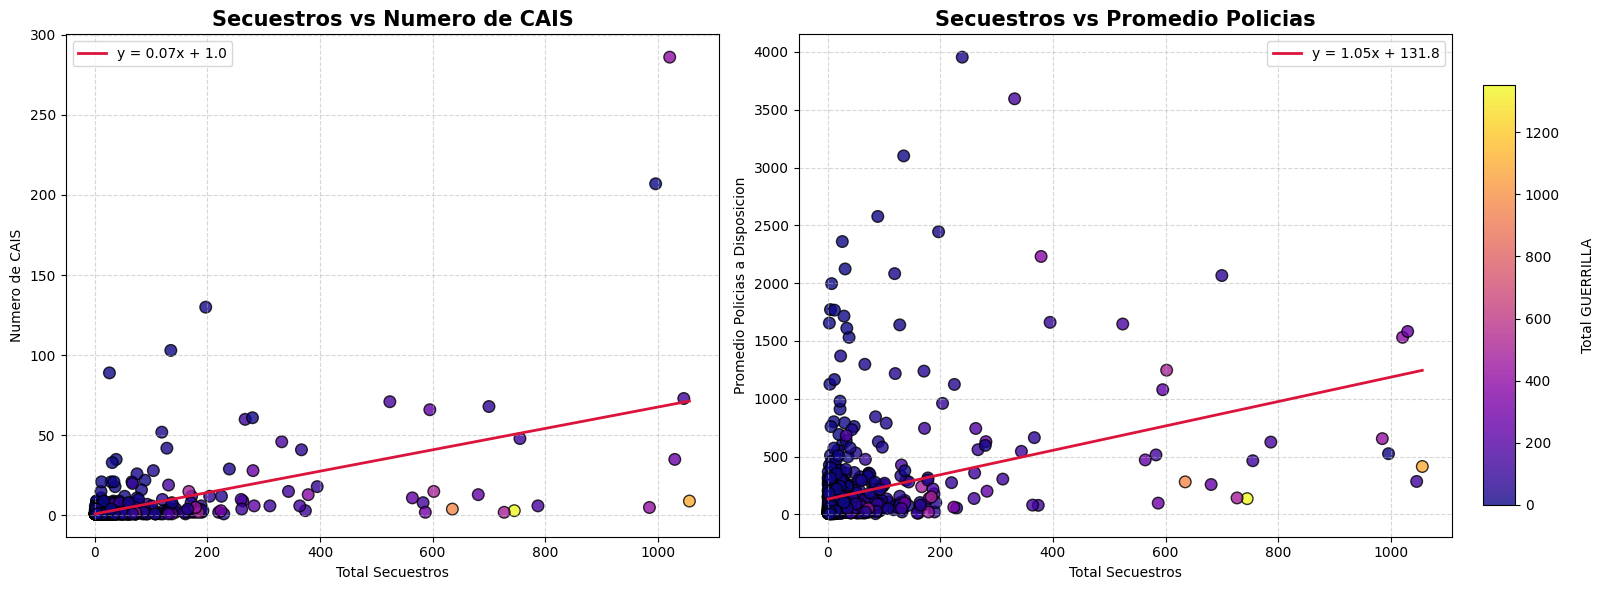

In [143]:

# Agrupar datos
temp = base_sec_violen_seguridad.groupby(['MUNICIPIO']).agg(
    secuestros=('TOTAL', 'sum'),
    cais=('num_cai', 'mean'),
    guerrilla=('GUERRILLA', 'sum'),
    paras =('GRUPO PARAMILITAR', 'sum'),
    n_seguridad=('avg_integrantes', 'mean')
).reset_index()


# Crear varuables temporales para graficar
x1 = temp['secuestros']
y1 = temp['cais']
c1 = temp['guerrilla'] + temp['paras']

mask1 = x1.notna() & y1.notna() & c1.notna() & np.isfinite(x1) & np.isfinite(y1) & np.isfinite(c1)
x1_clean = x1[mask1]
y1_clean = y1[mask1]
c1_clean = c1[mask1]
m1, b1 = np.polyfit(x1_clean, y1_clean, 1)
x2 = temp['secuestros']
y2 = temp['n_seguridad']
c2 = temp['guerrilla'] + temp['paras']


mask = temp[['secuestros', 'cais', 'n_seguridad', 'guerrilla']].notna().all(axis=1)
mask &= np.isfinite(temp[['secuestros', 'cais', 'n_seguridad', 'guerrilla']]).all(axis=1)
data = temp[mask]

x1, y1, c = data['secuestros'], data['cais'], data['guerrilla'] + data['paras']
m1, b1 = np.polyfit(x1, y1, 1)
x2, y2 = data['secuestros'], data['n_seguridad']
m2, b2 = np.polyfit(x2, y2, 1)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

# Primer scatter + regresión

sc1 = ax1.scatter(x1, y1, c=c, cmap='plasma', s=70, alpha=0.8, edgecolor='k')
ax1.plot(np.linspace(x1.min(), x1.max(), 200),m1 * np.linspace(x1.min(), x1.max(), 200) + b1,
         color='crimson', lw=2, label=f'y = {m1:.2f}x + {b1:.1f}')

ax1.set_title('Secuestros vs Numero de CAIS' , fontsize=15, weight='bold')
ax1.set_xlabel('Total Secuestros')
ax1.set_ylabel('Numero de CAIS')
ax1.legend()
ax1.grid(True, ls='--', alpha=0.5)

# Segundo scatter + regresión
sc2 = ax2.scatter(x2, y2, c=c, cmap='plasma', s=70, alpha=0.8, edgecolor='k')
ax2.plot(np.linspace(x2.min(), x2.max(), 200),m2 * np.linspace(x2.min(), x2.max(), 200) + b2,
         color='crimson', lw=2, label=f'y = {m2:.2f}x + {b2:.1f}')

ax2.set_title('Secuestros vs Promedio Policias', fontsize=15 , weight='bold')
ax2.set_xlabel('Total Secuestros')
ax2.set_ylabel('Promedio Policias a Disposicion')
ax2.legend()
ax2.grid(True, ls='--', alpha=0.5)

cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])  
cbar = fig.colorbar(sc1, cax=cbar_ax)
cbar.set_label('Total GUERRILLA', rotation=90, labelpad=15)

plt.tight_layout(rect=[0, 0, 0.92, 1])  
plt.show()


En ambos gráficos cada punto es un municipio y el degradado de color indica el tamaño de la guerrilla local.

1. **Secuestros vs CAIs**  
   La recta de regresión (y = 0.07 x + 1.7) muestra una relación positiva moderada: por cada 10 secuestros adicionales el número de CAIs crece en aproximadamente 0.07. La razon por la que la regresion tiene un beta estimado positivo puede entenderse desde principalmente: las ciudades con mas cais y mas secuestros pueden ser las que mas poblacion tiene. 
   
   Como mencionamos anteriormente, municipios con mayor presencia guerrillera (puntos más claros) tienden a situarse en la parte baja, confirmando que donde hubo más guerrilla habia poca ley y en varios casos mas secuestros.

2. **Secuestros vs Promedio de policías**  
   Aquí la pendiente es aun mayor (y = 1.05 x + 140.7), lo que indica que cada 10 secuestros adicionales se asocian con casi 10 policías más en promedio. La nube de puntos es más dispersa, pero de nuevo los municipios con alta guerrilla (colores claros) coinciden con valores altos en el eje X (indicando mas secuestros) y menos policias.  

En conjunto, estos gráficos sugieren que el Estado tenia varias zonas perdidas por la guerrilla, zonas donde se potenciaban los secuestros. Para confirmar nuestra hipotesis de que la correlacion positiva de la regresion viene dada porque las ciudades mas grandes tienen (simplemente por mas gente) mas secuestros y mayor seguridad, podemos volver a calcular esta grafica y la regresion pero con el indice de secuestros por cads 100k habitantes. Si el coeficiente pasa a ser negativo significa que en los pueblos pequeños, en donde ya vimos que hay mayor tasa de secuestros y guerilla, es donde menos ley habia y mayores secuestros habian 


C:\Users\alejo\AppData\Local\Temp\ipykernel_4176\1133697258.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1])


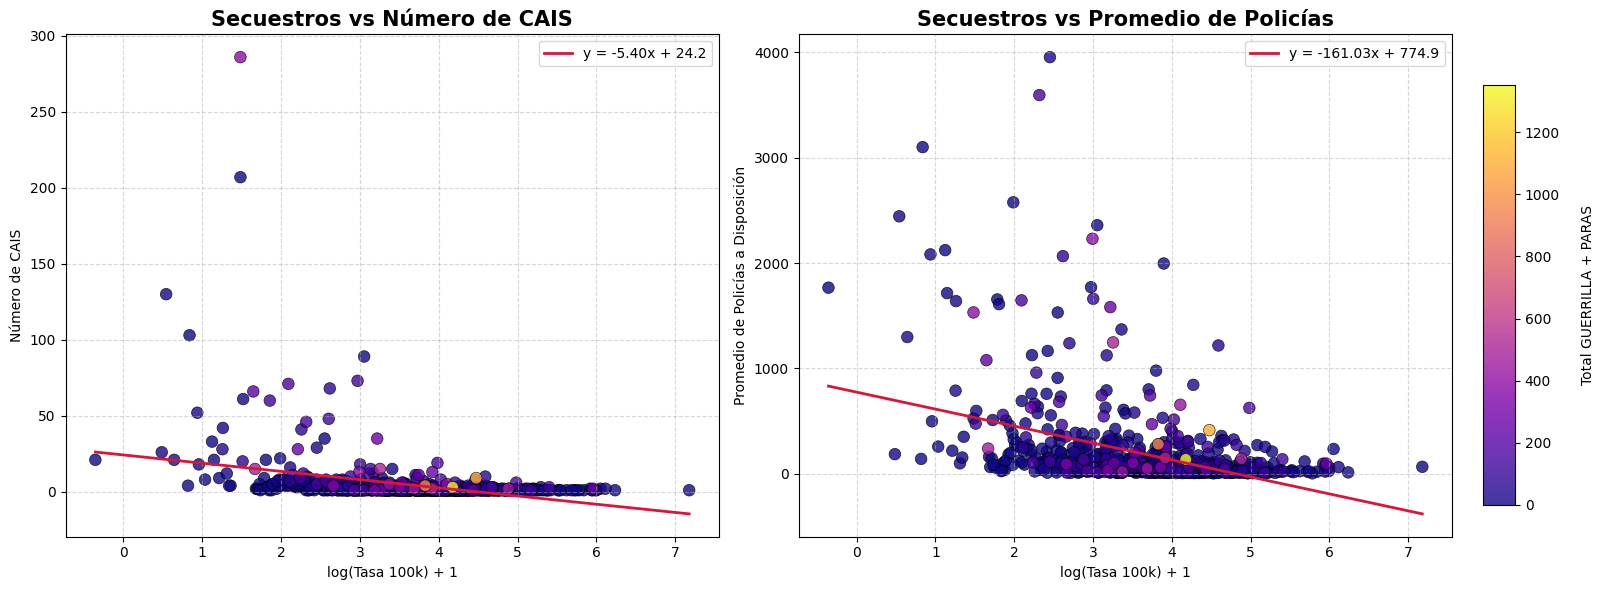

In [139]:
# Agrupar datos
temp = base_sec_violen_seguridad.groupby(['MUNICIPIO']).agg(
    secuestros=('Tasa_100k', 'mean'),
    cais=('num_cai', 'mean'),
    guerrilla=('GUERRILLA', 'sum'),
    paras =('GRUPO PARAMILITAR', 'sum'),
    n_seguridad=('avg_integrantes', 'mean')
).reset_index()

mask = temp[['secuestros','cais','guerrilla','paras','n_seguridad']].notna().all(axis=1)
mask &= np.isfinite(temp[['secuestros','cais','guerrilla','paras','n_seguridad']]).all(axis=1)
data = temp[mask]

x1 = np.log(data['secuestros']) + 1
y1 = data['cais']
c  = data['guerrilla'] + data['paras']

x2 = np.log(data['secuestros']) + 1
y2 = data['n_seguridad']

# Filtrar únicamente valores finitos tras la transformación
mask2 = np.isfinite(x1) & np.isfinite(y1) & np.isfinite(c)
x1_clean = x1[mask2]
y1_clean = y1[mask2]
c_clean = c[mask2]
x2_clean = x2[mask2]
y2_clean = y2[mask2]

# Ordenar de menor a mayor 'c' para que los puntos con más violencia queden encima
order = np.argsort(c_clean)
x1_ord, y1_ord, c_ord = x1_clean.values[order], y1_clean.values[order], c_clean.values[order]
x2_ord, y2_ord        = x2_clean.values[order], y2_clean.values[order]

# Ajuste de la regresión lineal
m1, b1 = np.polyfit(x1_clean, y1_clean, 1)
m2, b2 = np.polyfit(x2_clean, y2_clean, 1)

# Creación de la figura con 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharex=True)


sc1 = ax1.scatter(x1_ord, y1_ord,c=c_ord, cmap='plasma',s=70, alpha=0.8,edgecolor='k', linewidth=0.5)
x1_line = np.linspace(x1_clean.min(), x1_clean.max(), 200)
ax1.plot(x1_line, m1*x1_line + b1,color='crimson', lw=2,
    label=f'y = {m1:.2f}x + {b1:.1f}')

ax1.set_title('Secuestros vs Número de CAIS', fontsize=15, weight='bold')
ax1.set_xlabel('log(Tasa 100k) + 1')
ax1.set_ylabel('Número de CAIS')
ax1.legend()
ax1.grid(True, ls='--', alpha=0.5)

sc2 = ax2.scatter(x2_ord, y2_ord,
    c=c_ord, cmap='plasma',s=70, alpha=0.8,edgecolor='k', linewidth=0.5)
x2_line = np.linspace(x2_clean.min(), x2_clean.max(), 200)
ax2.plot(x2_line, m2*x2_line + b2,color='crimson', lw=2,
    label=f'y = {m2:.2f}x + {b2:.1f}')

ax2.set_title('Secuestros vs Promedio de Policías', fontsize=15, weight='bold')
ax2.set_xlabel('log(Tasa 100k) + 1')
ax2.set_ylabel('Promedio de Policías a Disposición')
ax2.legend()
ax2.grid(True, ls='--', alpha=0.5)

cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7]) 
cbar = fig.colorbar(sc1, cax=cbar_ax)
cbar.set_label('Total GUERRILLA + PARAS', rotation=90, labelpad=15)

plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()

Al usar el logaritmo de la tasa de secuestros por 100 000 habitantes en el eje X (modelo lin-log), observamos que:

1. **CAIs vs log-tasa**  
   La pendiente es negativa (β≈−5.40), lo que significa que un aumento porcentual en la tasa de secuestros se asocia con **menos** puestos policiales fijos. Los puntos **más claros** (municipios con mayor fuerza guerrillera) aparecen a la derecha (alta tasa) y abajo (pocos CAIs), confirmando que las zonas de mayor violencia tuvieron menor cobertura institucional.

2. **Policías vs log-tasa**  
   De forma análoga, la pendiente negativa (β≈−161) indica que un incremento proporcional en la tasa de secuestros va acompañado de una **reducción** en el promedio de policías disponibles. Nuevamente, los puntos claros se concentran en el cuadrante de alta tasa y baja dotación policial.

En conjunto, este modelo lin-log revela que, una vez corregido por población, los municipios con más guerrilla, y por tanto con las tasas más elevadas, eran paradójicamente los menos atendidos por las fuerzas de seguridad.  


### Exportar base para el modelamiento 

In [141]:
base_sec_violen_seguridad.to_csv('Base_Final.csv', index=False, encoding='utf-8')

## Concluciones parte 2 

En esta segunda fase combinamos la **tasa de secuestros por 100 000 habitantes**, proxies de **violencia armada** (acciones bélicas, asesinatos selectivos, masacres) y datos de **presencia institucional** (CAIs y promedio de policías) para entender de mejor forma como se distribuian los secuestros en el pais
:

1. **Tasa de secuestro**  
   - Los municipios y departamentos con las tasas más altas no fueron necesariamente los más poblados, sino aquellos con población reducida en los Llanos y la zona sur (Vaupés, Guaviare, Caquetá, Meta). Allí unos pocos secuestros elevan la tasa por habitante a niveles extremos, reflejando el impacto poblacional de las “pescas milagrosas” durante el apogeo de la guerrilla.

2. **Proxy de violencia**  
   - Las burbujas de masacres, la señal más directa de presencia guerrillera, coinciden casi perfectamente con los focos de secuestro, reforzando que los epicentros de la violencia armada fueron también los núcleos de rapto más intensos.  
   - Las acciones bélicas y asesinatos selectivos mostraron una dispersión mayor, pero mantuvieron correlación con los mayores conteos de secuestros; esto evidencia las diferencias entre modalidades de violencia y la necesidad de escoger la proxy apropiada.

3. **Presencia institucional**  
   - Los análisis de regresión entre secuestros y número de CAIs o total de  policias mostraron relaciones positivas: los municipios con más secuestros y mayor policia recibieron un mayor despliegue de infraestructura y personal, pero nuestra hipotesis era que esto se debia a que las grandes ciudades estaban sesgado el coeficiente estimado .  
   - Al evaluar la relación con la **tasa** de secuestros (lin-log), la asociación invierte su signo: los municipios con mayores tasas, y por tanto con más presencia guerrillera, tienen **menos** CAIs y **menos** policías en promedio, lo cual significa directamente que la presencia instuticional del Estado era minima en estas zonas de alta violencia y tasas de secuestro.  
   - Esto muestra que la correlación positiva previa (en valores absolutos) estaba sesgada por el tamaño de la población y oculta una cobertura insuficiente en los lugares más golpeados.  

En conjunto, estos hallazgos confirman que la **tasa de secuestros normalizada** revela vulnerabilidades territoriales ocultas por los conteos absolutos, que la **violencia guerrillera** (especialmente las masacres) es la mejor señal de dónde se concentraron los secuestros, y que la **respuesta institucional** no siempre alcanzó los lugares de mayor necesidad de forma óptima. Estos insights sientan las bases para modelar determinantes socioeconómicos y diseñar intervenciones focalizadas en las zonas de mayor riesgo.
 